# Human3.6M via GCS: data investigation + staged ViT adapter training

This notebook follows the same idea as `ViT.ipynb`, but is organized for the original Human3.6M data in GCS.

Pipeline:
1. Authenticate and inspect dataset structure in GCS
2. Build a manifest and downsample with SPIN-like frame selection
3. Inspect annotation formats and create unified supervision targets
4. Train ViT + adapter + SPIN regressor head on a small pilot
5. Expand to larger training if pilot metrics are acceptable

In [42]:
# Core setup and authentication
import os
import re
import json
import math
import time
import random
import shutil
import tarfile
import zipfile
import pathlib
import subprocess
from dataclasses import dataclass

import numpy as np
import pandas as pd

try:
    from google.colab import auth, drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

PROJECT_ID = "project-2f9fd1c8-00f8-4801-b48"
BUCKET_NAME = "artem-bucket-01"
FOLDER = "human3.6m"
GCS_PREFIX = f"gs://{BUCKET_NAME}/{FOLDER}"

WORKDIR = "/content" if os.path.exists("/content") else str(pathlib.Path.cwd())
LOCAL_ROOT = os.path.join(WORKDIR, "h36m_work")
LOCAL_DATA = os.path.join(LOCAL_ROOT, "data")
LOCAL_META = os.path.join(LOCAL_ROOT, "meta")
LOCAL_PILOT = os.path.join(LOCAL_ROOT, "pilot")
LOCAL_FULL = os.path.join(LOCAL_ROOT, "full")

for p in [LOCAL_ROOT, LOCAL_DATA, LOCAL_META, LOCAL_PILOT, LOCAL_FULL]:
    os.makedirs(p, exist_ok=True)

if IN_COLAB:
    auth.authenticate_user()
    drive.mount('/content/drive', force_remount=False)

print("Workspace:", LOCAL_ROOT)
print("GCS prefix:", GCS_PREFIX)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Workspace: /content/h36m_work
GCS prefix: gs://artem-bucket-01/human3.6m


In [43]:
# Utilities for shell commands and GCS listing
def run_cmd(cmd, check=True, capture=True):
    print("$", cmd)
    p = subprocess.run(
        cmd,
        shell=True,
        check=False,
        stdout=subprocess.PIPE if capture else None,
        stderr=subprocess.STDOUT if capture else None,
        text=True
    )
    if capture and p.stdout:
        print(p.stdout[:4000])
    if check and p.returncode != 0:
        raise RuntimeError(f"Command failed ({p.returncode}): {cmd}")
    return p

run_cmd(f"gcloud config set project {PROJECT_ID}")

def gcs_recursive_ls(prefix):
    # gcloud storage is preferred over gsutil in fresh Colab environments
    cmd = f"gcloud storage ls --recursive {prefix}/**"
    out = run_cmd(cmd).stdout or ""
    lines = [ln.strip() for ln in out.splitlines() if ln.strip().startswith("gs://")]
    return lines

all_blobs = gcs_recursive_ls(GCS_PREFIX)
print(f"Total objects discovered: {len(all_blobs):,}")

$ gcloud config set project project-2f9fd1c8-00f8-4801-b48


Project 'project-2f9fd1c8-00f8-4801-b48' lacks an 'environment' tag. Please create or add a tag with key 'environment' and a value like 'Production', 'Development', 'Test', or 'Staging'. Add an 'environment' tag using `gcloud resource-manager tags bindings create`. See https://cloud.google.com/resource-manager/docs/creating-managing-projects#designate_project_environments_with_tags for details.
Updated property [core/project].

$ gcloud storage ls --recursive gs://artem-bucket-01/human3.6m/**
gs://artem-bucket-01/human3.6m/HM36_annot.zip
gs://artem-bucket-01/human3.6m/Poses_D2_Positions_S1.tgz
gs://artem-bucket-01/human3.6m/Poses_D2_Positions_S11.tgz
gs://artem-bucket-01/human3.6m/Poses_D2_Positions_S5.tgz
gs://artem-bucket-01/human3.6m/Poses_D2_Positions_S6.tgz
gs://artem-bucket-01/human3.6m/Poses_D2_Positions_S7.tgz
gs://artem-bucket-01/human3.6m/Poses_D2_Positions_S8.tgz
gs://artem-bucket-01/human3.6m/Poses_D2_Positions_S9.tgz
gs://artem-bucket-01/human3.6m/Poses_D3_Positions_S1.tgz

In [44]:
# Build manifest and inspect structure (archive-aware)
def split_blob(uri):
    rel = uri.replace(f"gs://{BUCKET_NAME}/", "")
    ext = pathlib.Path(rel).suffix.lower()
    return rel, ext

rows = []
for u in all_blobs:
    rel, ext = split_blob(u)
    low = rel.lower()
    rows.append({
        "uri": u,
        "rel": rel,
        "ext": ext,
        "is_image": ext in {".jpg", ".jpeg", ".png"},
        "is_archive": ext in {".tar", ".gz", ".tgz", ".zip"},
        "is_annotation": (
            ext in {".npz", ".npy", ".json", ".pkl", ".mat", ".cdf", ".csv"}
            or "annot" in low
            or "pose" in low
            or "segment" in low
            or "bbox" in low
        )
    })

manifest = pd.DataFrame(rows)
manifest.to_csv(os.path.join(LOCAL_META, "gcs_manifest.csv"), index=False)

print("Top extensions:")
print(manifest["ext"].value_counts().head(20))

print("\nExample paths:")
for p in manifest["rel"].head(20).tolist():
    print("  ", p)

img_manifest = manifest[manifest.is_image].copy()
archive_manifest = manifest[manifest.is_archive].copy()
ann_manifest = manifest[manifest.is_annotation].copy()

print(f"\nImages: {len(img_manifest):,}")
print(f"Archives: {len(archive_manifest):,}")
print(f"Annotation-like files: {len(ann_manifest):,}")

print("\nArchive examples:")
for p in archive_manifest["rel"].head(20).tolist():
    print("  ", p)

Top extensions:
ext
.tgz    94
.zip     2
Name: count, dtype: int64

Example paths:
   human3.6m/HM36_annot.zip
   human3.6m/Poses_D2_Positions_S1.tgz
   human3.6m/Poses_D2_Positions_S11.tgz
   human3.6m/Poses_D2_Positions_S5.tgz
   human3.6m/Poses_D2_Positions_S6.tgz
   human3.6m/Poses_D2_Positions_S7.tgz
   human3.6m/Poses_D2_Positions_S8.tgz
   human3.6m/Poses_D2_Positions_S9.tgz
   human3.6m/Poses_D3_Positions_S1.tgz
   human3.6m/Poses_D3_Positions_S11.tgz
   human3.6m/Poses_D3_Positions_S5.tgz
   human3.6m/Poses_D3_Positions_S6.tgz
   human3.6m/Poses_D3_Positions_S7.tgz
   human3.6m/Poses_D3_Positions_S8.tgz
   human3.6m/Poses_D3_Positions_S9.tgz
   human3.6m/Poses_D3_Positions_mono_S1.tgz
   human3.6m/Poses_D3_Positions_mono_S11.tgz
   human3.6m/Poses_D3_Positions_mono_S5.tgz
   human3.6m/Poses_D3_Positions_mono_S6.tgz
   human3.6m/Poses_D3_Positions_mono_S7.tgz

Images: 0
Archives: 96
Annotation-like files: 85

Archive examples:
   human3.6m/HM36_annot.zip
   human3.6m/Poses_D2_

In [45]:
# Extract Human3.6M-style grouping fields from image or archive paths
def extract_subject(path):
    m = re.search(r"(?:^|/|_)(S\d+)(?:/|_|\.|$)", path, flags=re.IGNORECASE)
    return m.group(1).upper() if m else "UNK"

def extract_camera(path):
    m = re.search(r"\.(\d{8})\.", path)
    return m.group(1) if m else "UNK"

def extract_action(path):
    fname = os.path.basename(path)
    m = re.match(r"S\d+_([^\.]+)\.", fname, flags=re.IGNORECASE)
    return m.group(1) if m else "UNK"

if len(img_manifest) > 0:
    img_manifest["subject"] = img_manifest["rel"].map(extract_subject)
    img_manifest["camera"] = img_manifest["rel"].map(extract_camera)
    img_manifest["action"] = img_manifest["rel"].map(extract_action)

if len(archive_manifest) > 0:
    archive_manifest["subject"] = archive_manifest["rel"].map(extract_subject)
    archive_manifest["kind"] = archive_manifest["rel"].str.extract(
        r"(videos|poses_d2_positions|poses_d3_positions_mono|poses_d3_positions|segments_mat_gt_bs|annot)",
        flags=re.IGNORECASE,
        expand=False
    ).fillna("other").str.lower()

print("Image subjects:")
print(img_manifest.get("subject", pd.Series(dtype=str)).value_counts().head(20))

print("\nArchive subjects:")
print(archive_manifest.get("subject", pd.Series(dtype=str)).value_counts().head(20))

print("\nArchive kinds:")
print(archive_manifest.get("kind", pd.Series(dtype=str)).value_counts().head(20))

if len(img_manifest) == 0:
    print("\nNo direct image files found; using archive-first pipeline.")

Image subjects:
Series([], Name: count, dtype: int64)

Archive subjects:
subject
S1     14
S11    14
S8     14
S6     14
S7     13
S9     13
S5     12
UNK     2
Name: count, dtype: int64

Archive kinds:
kind
videos                     56
poses_d3_positions_mono    14
poses_d2_positions          7
segments_mat_gt_bs          7
poses_d3_positions          7
other                       4
annot                       1
Name: count, dtype: int64

No direct image files found; using archive-first pipeline.


In [46]:
# Plan pilot/full subsets from archives (not from raw image blobs)
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Increased sample sizes for stronger supervision coverage
pilot_target = 4000
full_target = 20000
frame_stride = 5  # SPIN-inspired
pilot_subjects = ["S1", "S5"]
full_subjects = ["S1", "S5", "S6", "S7", "S8"]

def pick_archives_for_subjects(df, subjects, include_kinds=None):
    d = df.copy()
    if "subject" in d.columns:
        d = d[d["subject"].isin(subjects)]
    if include_kinds is not None and "kind" in d.columns:
        d = d[d["kind"].isin(include_kinds)]
    return d

required_kinds = {
    "videos",
    "poses_d3_positions_mono",
    "poses_d2_positions",
    "segments_mat_gt_bs",
    "annot"
}

pilot_archives = pick_archives_for_subjects(
    archive_manifest, pilot_subjects, include_kinds=required_kinds
).copy()
full_archives = pick_archives_for_subjects(
    archive_manifest, full_subjects, include_kinds=required_kinds
).copy()

# Always include HM36 annotation zip if present
hm36_annot = archive_manifest[archive_manifest["rel"].str.lower().str.contains("hm36_annot.zip", regex=False)]
if len(hm36_annot) > 0:
    pilot_archives = pd.concat([pilot_archives, hm36_annot]).drop_duplicates(subset=["uri"])
    full_archives = pd.concat([full_archives, hm36_annot]).drop_duplicates(subset=["uri"])

pilot_archives.to_csv(os.path.join(LOCAL_META, "pilot_archives.csv"), index=False)
full_archives.to_csv(os.path.join(LOCAL_META, "full_archives.csv"), index=False)

print(f"Pilot archives planned: {len(pilot_archives):,}")
print(f"Full archives planned:  {len(full_archives):,}")
print("\nPilot archive sample:")
display(pilot_archives[["rel", "subject", "kind"]].head(20))

Pilot archives planned: 24
Full archives planned:  61

Pilot archive sample:


,rel,subject,kind
1,human3.6m/Poses_D2_Positions_S1.tgz,S1,poses_d2_positions
3,human3.6m/Poses_D2_Positions_S5.tgz,S5,poses_d2_positions
15,human3.6m/Poses_D3_Positions_mono_S1.tgz,S1,poses_d3_positions_mono
17,human3.6m/Poses_D3_Positions_mono_S5.tgz,S5,poses_d3_positions_mono
22,human3.6m/Poses_D3_Positions_mono_universal_S1...,S1,poses_d3_positions_mono
24,human3.6m/Poses_D3_Positions_mono_universal_S5...,S5,poses_d3_positions_mono
29,human3.6m/Segments_mat_gt_bs_S1.tgz,S1,segments_mat_gt_bs
31,human3.6m/Segments_mat_gt_bs_S5.tgz,S5,segments_mat_gt_bs
39,human3.6m/Videos_S1.tgz,S1,videos
41,human3.6m/Videos_S5.tgz,S5,videos


In [47]:
# Download and extract archives, then build frame-level manifests WITH matched H3.6M annotations
import cv2
import h5py
from spacepy import pycdf

LOCAL_ARCHIVES = os.path.join(LOCAL_ROOT, "archives")
LOCAL_EXTRACT = os.path.join(LOCAL_ROOT, "extracted")
LOCAL_PILOT_IMG = os.path.join(LOCAL_PILOT, "images")
LOCAL_FULL_IMG = os.path.join(LOCAL_FULL, "images")
for p in [LOCAL_ARCHIVES, LOCAL_EXTRACT, LOCAL_PILOT_IMG, LOCAL_FULL_IMG]:
    os.makedirs(p, exist_ok=True)

def local_archive_path(uri):
    rel = uri.replace(f"gs://{BUCKET_NAME}/", "")
    return os.path.join(LOCAL_ARCHIVES, rel)

def download_archives(df):
    for i, uri in enumerate(df["uri"].tolist(), 1):
        dst = local_archive_path(uri)
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        if not os.path.exists(dst):
            run_cmd(f"gcloud storage cp '{uri}' '{dst}'", check=False, capture=False)
        if i % 10 == 0:
            print(f"Downloaded {i}/{len(df)} archives")

def extract_archive(path, out_root):
    low = path.lower()
    if low.endswith(".zip"):
        with zipfile.ZipFile(path, "r") as zf:
            zf.extractall(out_root)
    elif low.endswith(".tgz") or low.endswith(".tar.gz") or low.endswith(".tar"):
        with tarfile.open(path, "r:*") as tf:
            tf.extractall(out_root)

def extract_archives(df, out_root):
    for i, uri in enumerate(df["uri"].tolist(), 1):
        src = local_archive_path(uri)
        if not os.path.exists(src):
            continue
        try:
            extract_archive(src, out_root)
        except Exception as e:
            print("Extract failed:", src, e)
        if i % 10 == 0:
            print(f"Extracted {i}/{len(df)} archives")

download_archives(pilot_archives)
extract_archives(pilot_archives, LOCAL_EXTRACT)

# Build indexes for annotation files extracted from the SAME dataset
cdf_files = sorted(pathlib.Path(LOCAL_EXTRACT).rglob('*.cdf'))
mat_files = sorted(pathlib.Path(LOCAL_EXTRACT).rglob('*.mat'))

cdf_by_name = {}
for p in cdf_files:
    cdf_by_name[p.name.lower()] = str(p)

mat_by_name = {}
for p in mat_files:
    mat_by_name[p.name.lower()] = str(p)

# Find extracted videos
video_files = []
for ext in ["*.mp4", "*.avi", "*.mov", "*.mkv"]:
    video_files.extend(pathlib.Path(LOCAL_EXTRACT).rglob(ext))
video_files = sorted(set(video_files))

print(f"Extracted videos found: {len(video_files)}")
for v in video_files[:10]:
    print(" -", v)

# SPIN joint mapping from raw H36M 32 joints to global 24
h36m_idx = [11, 6, 7, 8, 1, 2, 3, 12, 24, 14, 15, 17, 18, 19, 25, 26, 27]
global_idx = [14, 3, 4, 5, 2, 1, 0, 16, 12, 17, 18, 9, 10, 11, 8, 7, 6]

def infer_subject_from_path(vpath):
    vp = str(vpath).replace('\\', '/')
    m = re.search(r"/(S\d+)(?:/|$)", vp, flags=re.IGNORECASE)
    return m.group(1).upper() if m else "UNK"

def video_stem_to_candidates(stem):
    # Handle Human3.6M naming variants: "Directions 1.54138969" vs "Directions.54138969"
    cands = {stem}
    cands.add(stem.replace(' 1.', '.'))
    cands.add(stem.replace(' 2.', '.'))
    cands.add(stem.replace(' ', '_'))
    cands.add(stem.replace(' ', ''))
    return list(cands)

def lookup_cdf_for_video(vpath):
    stem = pathlib.Path(vpath).stem
    for s in video_stem_to_candidates(stem):
        key = (s + '.cdf').lower()
        if key in cdf_by_name:
            return cdf_by_name[key]
    return None

def lookup_mat_for_video(vpath):
    stem = pathlib.Path(vpath).stem
    for s in video_stem_to_candidates(stem):
        key = (s + '.mat').lower()
        if key in mat_by_name:
            return mat_by_name[key]
    return None

def read_bbox_from_mat(mat_path, frame_idx):
    try:
        with h5py.File(mat_path, 'r') as f:
            ref = f['Masks'][frame_idx, 0]
            mask = f[ref][()].T
            ys, xs = np.where(mask == 1)
            if len(xs) == 0 or len(ys) == 0:
                return None, None
            bbox = np.array([np.min(xs), np.min(ys), np.max(xs) + 1, np.max(ys) + 1], dtype=np.float32)
            center = np.array([(bbox[2] + bbox[0]) / 2.0, (bbox[3] + bbox[1]) / 2.0], dtype=np.float32)
            scale = np.float32(0.9 * max(bbox[2] - bbox[0], bbox[3] - bbox[1]) / 200.0)
            return center, scale
    except Exception:
        return None, None

def sample_frames_with_annotations(videos, out_dir, max_images, stride=5):
    os.makedirs(out_dir, exist_ok=True)

    # Create round-robin capture pool
    caps = []
    for v in videos:
        cap = cv2.VideoCapture(str(v))
        if not cap.isOpened():
            continue
        cdf_path = lookup_cdf_for_video(v)
        if cdf_path is None:
            cap.release()
            continue
        mat_path = lookup_mat_for_video(v)
        caps.append((v, cap, 0, cdf_path, mat_path))

    print('Videos with matched D3 cdf:', len(caps))

    manifest_records = []
    ann_records = []
    saved = 0
    active = True

    # Cache opened CDF poses to avoid re-reading
    cdf_cache = {}

    while active and saved < max_images:
        active = False
        new_caps = []

        for v, cap, idx, cdf_path, mat_path in caps:
            ok, frame = cap.read()
            if not ok:
                cap.release()
                continue
            active = True

            if idx % stride == 0:
                if cdf_path not in cdf_cache:
                    try:
                        cdf_cache[cdf_path] = pycdf.CDF(cdf_path)['Pose'][0]
                    except Exception:
                        cdf_cache[cdf_path] = None

                poses_3d = cdf_cache[cdf_path]
                if poses_3d is None or idx >= poses_3d.shape[0]:
                    new_caps.append((v, cap, idx + 1, cdf_path, mat_path))
                    continue

                # Build SPIN-style 24x4 joint target from raw H36M 32x3
                Sall = np.reshape(poses_3d[idx, :], [-1, 3]).astype(np.float32) / 1000.0
                S17 = Sall[h36m_idx]
                S17 -= S17[0]
                S24 = np.zeros([24, 4], dtype=np.float32)
                S24[global_idx, :3] = S17
                S24[global_idx, 3] = 1.0

                center, scale = (None, None)
                if mat_path is not None:
                    center, scale = read_bbox_from_mat(mat_path, idx)
                if center is None:
                    center = np.array([frame.shape[1] / 2.0, frame.shape[0] / 2.0], dtype=np.float32)
                    scale = np.float32(max(frame.shape[1], frame.shape[0]) / 200.0)

                base = v.stem.replace(' ', '_').replace('.', '_')
                subject = infer_subject_from_path(v)
                parent_token = '_'.join(v.parts[-3:-1]).replace(' ', '_').replace('.', '_')
                rel = f"{subject}/{parent_token}_{base}_{idx:06d}.jpg"
                dst = os.path.join(out_dir, rel)
                os.makedirs(os.path.dirname(dst), exist_ok=True)

                if cv2.imwrite(dst, frame):
                    manifest_records.append({
                        'uri': '',
                        'rel': os.path.relpath(dst, out_dir).replace('\\\\', '/'),
                        'subject': subject,
                        'frame_idx': int(idx)
                    })
                    ann_records.append({
                        'rel': os.path.relpath(dst, out_dir).replace('\\\\', '/'),
                        'S': S24,
                        'center': center.astype(np.float32),
                        'scale': np.float32(scale)
                    })
                    saved += 1
                    if saved >= max_images:
                        cap.release()
                        break

            new_caps.append((v, cap, idx + 1, cdf_path, mat_path))

        caps = new_caps

    for _, cap, _, _, _ in caps:
        cap.release()

    manifest_df = pd.DataFrame(manifest_records).drop_duplicates(subset=['rel']).reset_index(drop=True)
    ann_rel = np.array([r['rel'] for r in ann_records], dtype=object)
    ann_S = np.stack([r['S'] for r in ann_records]).astype(np.float32) if ann_records else np.zeros((0, 24, 4), dtype=np.float32)
    ann_center = np.stack([r['center'] for r in ann_records]).astype(np.float32) if ann_records else np.zeros((0, 2), dtype=np.float32)
    ann_scale = np.array([r['scale'] for r in ann_records], dtype=np.float32) if ann_records else np.zeros((0,), dtype=np.float32)

    return manifest_df, ann_rel, ann_S, ann_center, ann_scale

pilot_manifest, ann_rel, ann_S, ann_center, ann_scale = sample_frames_with_annotations(
    video_files,
    LOCAL_PILOT_IMG,
    pilot_target,
    stride=frame_stride,
 )

pilot_manifest.to_csv(os.path.join(LOCAL_META, 'pilot_manifest.csv'), index=False)
np.savez(
    os.path.join(LOCAL_META, 'pilot_annotations.npz'),
    rel=ann_rel,
    S=ann_S,
    center=ann_center,
    scale=ann_scale,
)

print(f"Pilot sampled frames (manifest rows): {len(pilot_manifest):,}")
pilot_file_count = len(list(pathlib.Path(LOCAL_PILOT_IMG).rglob('*.jpg')))
print(f"Pilot sampled frames (files on disk): {pilot_file_count:,}")
print(f"Pilot annotations rows: {len(ann_rel):,}")
if pilot_file_count != len(pilot_manifest):
    print('Warning: manifest/file count mismatch detected.')

# Full run setup: only build full manifest after pilot evaluation
full_manifest = pd.DataFrame(columns=['uri', 'rel', 'subject'])
full_manifest.to_csv(os.path.join(LOCAL_META, 'full_manifest.csv'), index=False)
print('Full manifest is initialized empty; it will be generated after pilot evaluation.')

Downloaded 10/24 archives
Downloaded 20/24 archives


/tmp/ipykernel_499/524838307.py:33: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(out_root)


Extracted 10/24 archives
Extracted 20/24 archives
Extracted videos found: 640
 - /content/h36m_work/extracted/S1/Videos/Directions 1.54138969.mp4
 - /content/h36m_work/extracted/S1/Videos/Directions 1.55011271.mp4
 - /content/h36m_work/extracted/S1/Videos/Directions 1.58860488.mp4
 - /content/h36m_work/extracted/S1/Videos/Directions 1.60457274.mp4
 - /content/h36m_work/extracted/S1/Videos/Directions.54138969.mp4
 - /content/h36m_work/extracted/S1/Videos/Directions.55011271.mp4
 - /content/h36m_work/extracted/S1/Videos/Directions.58860488.mp4
 - /content/h36m_work/extracted/S1/Videos/Directions.60457274.mp4
 - /content/h36m_work/extracted/S1/Videos/Discussion 1.54138969.mp4
 - /content/h36m_work/extracted/S1/Videos/Discussion 1.55011271.mp4
Videos with matched D3 cdf: 600
Pilot sampled frames (manifest rows): 4,000
Pilot sampled frames (files on disk): 4,072
Pilot annotations rows: 4,000
Full manifest is initialized empty; it will be generated after pilot evaluation.


In [48]:
# Inspect extracted annotation files and confirm frame dataset
ann_files = []
for ext in [".npz", ".json", ".csv", ".npy", ".pkl", ".mat", ".cdf", ".zip"]:
    ann_files.extend(pathlib.Path(LOCAL_EXTRACT).rglob(f"*{ext}"))
ann_files = sorted(set(ann_files))

print(f"Found extracted annotation-like files: {len(ann_files)}")
for p in ann_files[:30]:
    print(" -", p)

pilot_disk_files = len(list(pathlib.Path(LOCAL_PILOT_IMG).rglob('*.jpg')))
pilot_manifest_rows = len(pilot_manifest)
print(f"\nPilot local frame images: {pilot_disk_files:,}")
print(f"Pilot manifest rows: {pilot_manifest_rows:,}")
if pilot_disk_files != pilot_manifest_rows:
    print("Warning: mismatch between manifest rows and local files.")
    # Keep only rows that really exist on disk to prevent training crashes.
    pilot_manifest = pilot_manifest[pilot_manifest['rel'].map(lambda r: os.path.exists(os.path.join(LOCAL_PILOT_IMG, r)))].reset_index(drop=True)
    pilot_manifest.to_csv(os.path.join(LOCAL_META, "pilot_manifest.csv"), index=False)
    print(f"Pilot manifest rows after cleanup: {len(pilot_manifest):,}")

if len(pilot_manifest) > 0:
    print("Pilot manifest sample:")
    display(pilot_manifest.head(10))

def preview_annotation(path):
    path = str(path)
    low = path.lower()
    print("\n==", path, "==")
    try:
        if low.endswith('.npz'):
            x = np.load(path, allow_pickle=True)
            print("keys:", list(x.keys()))
            for k in list(x.keys())[:5]:
                v = x[k]
                print(f"  {k}: shape={getattr(v, 'shape', None)} dtype={getattr(v, 'dtype', type(v))}")
        elif low.endswith('.json'):
            with open(path, 'r') as f:
                j = json.load(f)
            if isinstance(j, dict):
                print("dict keys:", list(j.keys())[:20])
            elif isinstance(j, list):
                print("list length:", len(j))
                if len(j) > 0:
                    print("first item type:", type(j[0]).__name__)
        elif low.endswith('.csv'):
            d = pd.read_csv(path, nrows=5)
            print("columns:", list(d.columns))
            print(d.head())
        elif low.endswith('.zip'):
            with zipfile.ZipFile(path, 'r') as zf:
                names = zf.namelist()
                print("zip entries:", len(names))
                print("first:", names[:15])
        else:
            print("No preview parser for this extension.")
    except Exception as e:
        print("Preview failed:", e)

for p in ann_files[:10]:
    preview_annotation(p)

Found extracted annotation-like files: 4330
 - /content/h36m_work/extracted/S1/MyPoseFeatures/D2_Positions/Directions 1.54138969.cdf
 - /content/h36m_work/extracted/S1/MyPoseFeatures/D2_Positions/Directions 1.55011271.cdf
 - /content/h36m_work/extracted/S1/MyPoseFeatures/D2_Positions/Directions 1.58860488.cdf
 - /content/h36m_work/extracted/S1/MyPoseFeatures/D2_Positions/Directions 1.60457274.cdf
 - /content/h36m_work/extracted/S1/MyPoseFeatures/D2_Positions/Directions.54138969.cdf
 - /content/h36m_work/extracted/S1/MyPoseFeatures/D2_Positions/Directions.55011271.cdf
 - /content/h36m_work/extracted/S1/MyPoseFeatures/D2_Positions/Directions.58860488.cdf
 - /content/h36m_work/extracted/S1/MyPoseFeatures/D2_Positions/Directions.60457274.cdf
 - /content/h36m_work/extracted/S1/MyPoseFeatures/D2_Positions/Discussion 1.54138969.cdf
 - /content/h36m_work/extracted/S1/MyPoseFeatures/D2_Positions/Discussion 1.55011271.cdf
 - /content/h36m_work/extracted/S1/MyPoseFeatures/D2_Positions/Discussion 

,uri,rel,subject,frame_idx
0,,S1/S1_Videos_Directions_1_54138969_000000.jpg,S1,0
1,,S1/S1_Videos_Directions_1_55011271_000000.jpg,S1,0
2,,S1/S1_Videos_Directions_1_58860488_000000.jpg,S1,0
3,,S1/S1_Videos_Directions_1_60457274_000000.jpg,S1,0
4,,S1/S1_Videos_Directions_54138969_000000.jpg,S1,0
5,,S1/S1_Videos_Directions_55011271_000000.jpg,S1,0
6,,S1/S1_Videos_Directions_58860488_000000.jpg,S1,0
7,,S1/S1_Videos_Directions_60457274_000000.jpg,S1,0
8,,S1/S1_Videos_Discussion_1_54138969_000000.jpg,S1,0
9,,S1/S1_Videos_Discussion_1_55011271_000000.jpg,S1,0



== /content/h36m_work/extracted/S1/MyPoseFeatures/D2_Positions/Directions 1.54138969.cdf ==
No preview parser for this extension.

== /content/h36m_work/extracted/S1/MyPoseFeatures/D2_Positions/Directions 1.55011271.cdf ==
No preview parser for this extension.

== /content/h36m_work/extracted/S1/MyPoseFeatures/D2_Positions/Directions 1.58860488.cdf ==
No preview parser for this extension.

== /content/h36m_work/extracted/S1/MyPoseFeatures/D2_Positions/Directions 1.60457274.cdf ==
No preview parser for this extension.

== /content/h36m_work/extracted/S1/MyPoseFeatures/D2_Positions/Directions.54138969.cdf ==
No preview parser for this extension.

== /content/h36m_work/extracted/S1/MyPoseFeatures/D2_Positions/Directions.55011271.cdf ==
No preview parser for this extension.

== /content/h36m_work/extracted/S1/MyPoseFeatures/D2_Positions/Directions.58860488.cdf ==
No preview parser for this extension.

== /content/h36m_work/extracted/S1/MyPoseFeatures/D2_Positions/Directions.60457274.cdf =

## SPIN insights and practical replacement for MoSH

From SPIN preprocessing/training code:
- Human3.6M sampling uses every 5th frame (`frame_i % 5 == 0`)
- They build center/scale from GT masks and keep root-centered 3D joints
- MoSH SMPL fits are not distributed due to license

Approximation strategy used here:
1. **Teacher pseudo-labels**: run pretrained SPIN on sampled images to get initial SMPL pose/betas/camera
2. **Optional refinement**: run SMPLify on a high-confidence subset to improve pseudo-fits
3. **Mixed supervision**: train ViT+adapter+SPIN head with pseudo-SMPL losses + GT 3D joint MPJPE where available

In [89]:
# Model setup (same family as ViT.ipynb)
import glob
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from PIL import Image

os.environ['PYOPENGL_PLATFORM'] = 'egl'

# Install deps once if needed (include chumpy for legacy SMPL pickle loading)
_ = run_cmd(
    'pip -q install smplx pyopengl pyrender trimesh torchgeometry spacepy git+https://github.com/mattloper/chumpy.git',
    check=False
 )

SPIN_ROOT = '/content/SPIN' if os.path.exists('/content') else os.path.join(str(pathlib.Path.cwd()), 'SPIN')
if not os.path.exists(SPIN_ROOT):
    run_cmd(f'git clone -q https://github.com/avasenin-14/SPIN {SPIN_ROOT}')

# Ensure relative paths in SPIN config resolve correctly
os.chdir(SPIN_ROOT)
print('Current working directory:', os.getcwd())

import sys
if SPIN_ROOT not in sys.path:
    sys.path.append(SPIN_ROOT)

# Fetch SPIN assets if missing
os.makedirs(os.path.join(SPIN_ROOT, 'data'), exist_ok=True)
if not os.path.exists(os.path.join(SPIN_ROOT, 'data', 'model_checkpoint.pt')):
    run_cmd(f"cd {SPIN_ROOT} ; wget -q http://visiondata.cis.upenn.edu/spin/data.tar.gz ; tar -xf data.tar.gz ; rm data.tar.gz", check=False)
    run_cmd(f"wget -q http://visiondata.cis.upenn.edu/spin/model_checkpoint.pt -P {os.path.join(SPIN_ROOT, 'data')}", check=False)
    run_cmd(f"wget -q https://github.com/vchoutas/smplify-x/raw/master/smplifyx/prior.py -O {os.path.join(SPIN_ROOT, 'smplify', 'prior.py')}", check=False)

from models.hmr import HMR, Bottleneck
from models.smpl import SMPL
from utils.geometry import rot6d_to_rotmat
from torchvision.models import vit_b_16, ViT_B_16_Weights
import config as spin_config

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

SMPL_MEAN_PARAMS = os.path.join(SPIN_ROOT, 'data', 'smpl_mean_params.npz')
CHECKPOINT_PATH = os.path.join(SPIN_ROOT, 'data', 'model_checkpoint.pt')
SMPL_MODEL_DIR = os.path.join(SPIN_ROOT, 'data', 'smpl')

FOCAL_LENGTH = 5000
IMG_RES = 224

if not os.path.exists(SMPL_MEAN_PARAMS) or not os.path.exists(CHECKPOINT_PATH):
    raise FileNotFoundError('SPIN assets are missing. Ensure data/model_checkpoint.pt and data/smpl_mean_params.npz exist.')

# Match ViT.ipynb behavior: copy SMPL model files from Drive if missing
os.makedirs(SMPL_MODEL_DIR, exist_ok=True)

name_map = {
    'SMPL_NEUTRAL.pkl': 'basicmodel_neutral_lbs_10_207_0_v1.1.0.pkl',
    'SMPL_MALE.pkl': 'basicmodel_m_lbs_10_207_0_v1.1.0.pkl',
    'SMPL_FEMALE.pkl': 'basicmodel_f_lbs_10_207_0_v1.1.0.pkl',
}

def discover_smpl_candidates():
    candidates = []

    # Exact ViT paths first
    fixed_dirs = [
        '/content/drive/MyDrive/dissertation/smpl/',
        '/content/drive/MyDrive/dissertation/SMPL/',
        '/content/drive/MyDrive/smpl/',
    ]
    for d in fixed_dirs:
        if os.path.isdir(d):
            candidates.append(d)

    # Recursive fallback: look for folders containing the expected original files
    search_roots = [
        '/content/drive/MyDrive',
        '/content/drive/Shareddrives',
    ]
    expected = set(name_map.values())
    for root in search_roots:
        if not os.path.isdir(root):
            continue
        for p in glob.glob(os.path.join(root, '**', '*.pkl'), recursive=True):
            if os.path.basename(p) in expected:
                d = os.path.dirname(p)
                if d not in candidates:
                    candidates.append(d)

    return candidates

def ensure_smpl_files(dst_dir, mapping):
    candidate_dirs = discover_smpl_candidates()
    print('SMPL candidate dirs discovered:', len(candidate_dirs))
    for d in candidate_dirs[:10]:
        print(' -', d)

    copied_total = 0
    for cand in candidate_dirs:
        copied = 0
        for new_name, orig_name in mapping.items():
            src = os.path.join(cand, orig_name)
            dst = os.path.join(dst_dir, new_name)
            if os.path.exists(src) and not os.path.exists(dst):
                shutil.copy(src, dst)
                copied += 1
        if copied > 0:
            copied_total += copied
            print(f'Copied {copied} SMPL files from {cand}')

    missing = [n for n in mapping.keys() if not os.path.exists(os.path.join(dst_dir, n))]
    print('SMPL files now in destination:', os.listdir(dst_dir) if os.path.isdir(dst_dir) else [])
    return missing, candidate_dirs, copied_total

missing_smpl, candidate_dirs, copied_total = ensure_smpl_files(SMPL_MODEL_DIR, name_map)
if missing_smpl:
    raise FileNotFoundError(
        'Missing SMPL files in SPIN/data/smpl: ' + ', '.join(missing_smpl) +
        '. Checked candidate dirs: ' + str(candidate_dirs[:10])
    )

# Ensure chumpy is importable before loading legacy SMPL .pkl files
try:
    import chumpy  # noqa: F401
except Exception:
    print('chumpy not available, attempting install...')
    run_cmd('pip -q install git+https://github.com/mattloper/chumpy.git', check=False)
    import chumpy  # noqa: F401

# Force SPIN config paths to absolute to avoid cwd-dependent failures
spin_config.JOINT_REGRESSOR_TRAIN_EXTRA = os.path.join(SPIN_ROOT, 'data', 'J_regressor_extra.npy')
spin_config.JOINT_REGRESSOR_H36M = os.path.join(SPIN_ROOT, 'data', 'J_regressor_h36m.npy')
spin_config.SMPL_MEAN_PARAMS = SMPL_MEAN_PARAMS
spin_config.SMPL_MODEL_DIR = SMPL_MODEL_DIR

if not os.path.exists(spin_config.JOINT_REGRESSOR_TRAIN_EXTRA):
    raise FileNotFoundError(
        'Missing required file: ' + spin_config.JOINT_REGRESSOR_TRAIN_EXTRA +
        '. Re-run SPIN data download in this cell.'
    )

spin_model = HMR(Bottleneck, [3, 4, 6, 3], SMPL_MEAN_PARAMS).to(device)
ckpt = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
spin_model.load_state_dict(ckpt['model'] if 'model' in ckpt else ckpt, strict=False)
spin_model.eval()

vit_weights = ViT_B_16_Weights.DEFAULT
vit_model = vit_b_16(weights=vit_weights).to(device)
vit_model.heads = nn.Identity()
vit_model.eval()

for p in vit_model.parameters():
    p.requires_grad = False

# Fine-tune only the last ViT encoder blocks with a very small LR.
VIT_TRAIN_LAST_N = 2  # set to 1 if you want a more conservative unfreeze
VIT_UNFREEZE_LR = 2e-6
vit_blocks = list(vit_model.encoder.layers.children())
for blk in vit_blocks[-VIT_TRAIN_LAST_N:]:
    for p in blk.parameters():
        p.requires_grad = True
for p in vit_model.encoder.ln.parameters():
    p.requires_grad = True
vit_trainable_params = [p for p in vit_model.parameters() if p.requires_grad]
print('ViT blocks unfrozen:', VIT_TRAIN_LAST_N)
print('ViT trainable params:', sum(p.numel() for p in vit_trainable_params))

adapter = nn.Sequential(
    nn.Linear(768, 1024),
    nn.GELU(),
    nn.Linear(1024, 2048)
).to(device)

regressor_params = []
for name, p in spin_model.named_parameters():
    if any(k in name for k in ['fc1', 'fc2', 'decpose', 'decshape', 'deccam']):
        p.requires_grad = False
        regressor_params.append(p)

smpl_layer = SMPL(SMPL_MODEL_DIR, batch_size=1).to(device)

train_transform = T.Compose([
    T.Resize((IMG_RES, IMG_RES)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

$ pip -q install smplx pyopengl pyrender trimesh torchgeometry spacepy git+https://github.com/mattloper/chumpy.git
Current working directory: /content/SPIN
Device: cuda
SMPL candidate dirs discovered: 2
 - /content/drive/MyDrive/dissertation/smpl/
 - /content/drive/MyDrive/dissertation/smpl
SMPL files now in destination: ['SMPL_MALE.pkl', 'SMPL_NEUTRAL.pkl', 'SMPL_FEMALE.pkl']
ViT blocks unfrozen: 2
ViT trainable params: 14177280


In [90]:
# Unified target loader from available annotation formats
def normalize_image_key(path):
    k = path.replace('\\', '/').lower()
    if '.' in os.path.basename(k):
        k = os.path.splitext(k)[0]
    return k

def build_gt_lookup_from_npz(npz_path):
    x = np.load(npz_path, allow_pickle=True)
    keys = list(x.keys())
    if 'imgname' not in keys:
        return {}

    imgname = x['imgname']
    S = x['S'] if 'S' in keys else None
    center = x['center'] if 'center' in keys else None
    scale = x['scale'] if 'scale' in keys else None

    out = {}
    for i, n in enumerate(imgname):
        nk = normalize_image_key(str(n))
        out[nk] = {
            'j3d': S[i] if S is not None else None,
            'center': center[i] if center is not None else None,
            'scale': scale[i] if scale is not None else None
        }
    return out

def build_gt_lookup_from_pilot_annotations(npz_path):
    if not os.path.exists(npz_path):
        return {}
    x = np.load(npz_path, allow_pickle=True)
    rel = x['rel']
    S = x['S']
    center = x['center']
    scale = x['scale']
    out = {}
    for i in range(len(rel)):
        nk = normalize_image_key(str(rel[i]))
        out[nk] = {
            'j3d': S[i],
            'center': center[i],
            'scale': scale[i]
        }
    return out

gt_lookup = {}

# Priority 1: annotations built from the same extracted Human3.6M videos
pilot_ann_path = os.path.join(LOCAL_META, 'pilot_annotations.npz')
gt_lookup.update(build_gt_lookup_from_pilot_annotations(pilot_ann_path))

# Priority 2: any additional h36m npz files discovered in extracted annotations
for p in ann_files:
    if str(p).lower().endswith('.npz') and 'h36m' in str(p).lower():
        cur = build_gt_lookup_from_npz(str(p))
        if len(cur) > 0:
            gt_lookup.update(cur)

print(f"Loaded GT lookup entries: {len(gt_lookup):,}")
if len(gt_lookup) > 0:
    k0 = next(iter(gt_lookup.keys()))
    print('Sample key:', k0)
    print('Sample value keys:', gt_lookup[k0].keys())

Loaded GT lookup entries: 4,000
Sample key: s1/s1_videos_directions_1_54138969_000000
Sample value keys: dict_keys(['j3d', 'center', 'scale'])


In [91]:
# Dataset and pseudo-label generation
class H36MImageDataset(Dataset):
    def __init__(self, local_root, manifest_df, transform, gt_lookup=None):
        self.local_root = local_root
        self.df = manifest_df.reset_index(drop=True).copy()
        self.transform = transform
        self.gt_lookup = gt_lookup or {}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        rel = row['rel']
        p = os.path.join(self.local_root, rel)
        img = Image.open(p).convert('RGB')

        x = self.transform(img)
        key = normalize_image_key(rel)
        gt = self.gt_lookup.get(key, None)

        j3d = None
        if gt is not None and gt.get('j3d', None) is not None:
            j = gt['j3d']
            if j.shape[-1] == 4:
                j = j[:, :3]
            j3d = torch.tensor(j, dtype=torch.float32)

        return {
            'image': x,
            'rel': rel,
            'j3d': j3d
        }

def collate_fn(batch):
    images = torch.stack([b['image'] for b in batch], dim=0)
    rels = [b['rel'] for b in batch]
    has_j3d = [b['j3d'] is not None for b in batch]

    if any(has_j3d):
        maxj = max([b['j3d'].shape[0] if b['j3d'] is not None else 0 for b in batch])
        j3d = torch.zeros((len(batch), maxj, 3), dtype=torch.float32)
        mask = torch.zeros((len(batch),), dtype=torch.bool)
        for i, b in enumerate(batch):
            if b['j3d'] is not None:
                n = b['j3d'].shape[0]
                j3d[i, :n] = b['j3d']
                mask[i] = True
    else:
        j3d = None
        mask = None

    return {'images': images, 'rels': rels, 'j3d': j3d, 'j3d_mask': mask}

# For archive workflow, rel paths are relative to LOCAL_PILOT/images
pilot_img_root = os.path.join(LOCAL_PILOT, 'images')
pilot_ds = H36MImageDataset(pilot_img_root, pilot_manifest, train_transform, gt_lookup=gt_lookup)
pilot_loader = DataLoader(pilot_ds, batch_size=16, shuffle=True, num_workers=2, collate_fn=collate_fn)

print('Pilot dataset:', len(pilot_ds))

Pilot dataset: 4000


In [92]:
# Regressor head helper + losses
def run_regressor(features_2048, spin_model, iters=3):
    B = features_2048.shape[0]
    pred_pose = spin_model.init_pose.expand(B, -1)
    pred_shape = spin_model.init_shape.expand(B, -1)
    pred_cam = spin_model.init_cam.expand(B, -1)
    for _ in range(iters):
        xc = torch.cat([features_2048, pred_pose, pred_shape, pred_cam], dim=1)
        xc = torch.relu(spin_model.fc1(xc))
        xc = spin_model.drop1(xc)
        xc = torch.relu(spin_model.fc2(xc))
        xc = spin_model.drop2(xc)
        pred_pose = pred_pose + spin_model.decpose(xc)
        pred_shape = pred_shape + spin_model.decshape(xc)
        pred_cam = pred_cam + spin_model.deccam(xc)
    return pred_pose, pred_shape, pred_cam

J_REG_PATH = os.path.join(SPIN_ROOT, 'data', 'J_regressor_h36m.npy')
j_regressor = None
if os.path.exists(J_REG_PATH):
    jr = np.load(J_REG_PATH)
    j_regressor = torch.tensor(jr, dtype=torch.float32).to(device)
    print('Loaded h36m regressor:', j_regressor.shape)

H36M_TO_17 = [0, 1, 2, 3, 6, 7, 8, 12, 13, 14, 15, 17, 18, 19, 25, 26, 27]

def pa_mpjpe_loss_torch(pred_rel, gt_rel, eps=1e-8):
    # Differentiable Protocol #2 proxy: similarity-aligned MPJPE in mm.
    losses = []
    B = pred_rel.shape[0]
    for b in range(B):
        X = pred_rel[b]
        Y = gt_rel[b]

        valid = (Y.abs().sum(dim=-1) > 1e-8)
        if int(valid.sum().item()) < 3:
            continue

        X = X[valid]
        Y = Y[valid]

        muX = X.mean(dim=0, keepdim=True)
        muY = Y.mean(dim=0, keepdim=True)
        X0 = X - muX
        Y0 = Y - muY

        K = X0.transpose(0, 1) @ Y0
        U, S, Vh = torch.linalg.svd(K)
        R = Vh.transpose(0, 1) @ U.transpose(0, 1)
        if torch.det(R) < 0:
            Vh_fix = Vh.clone()
            Vh_fix[-1, :] *= -1.0
            R = Vh_fix.transpose(0, 1) @ U.transpose(0, 1)

        varX = torch.sum(X0 * X0)
        scale = torch.sum(S) / (varX + eps)
        X_aligned = scale * (X0 @ R) + muY

        err = torch.norm((X_aligned - Y) * 1000.0, dim=-1).mean()
        losses.append(err)

    if len(losses) == 0:
        return torch.tensor(0.0, device=pred_rel.device)
    return torch.stack(losses).mean()

Loaded h36m regressor: torch.Size([17, 6890])


In [ ]:
# Pilot training (small sample first)
optimizer = torch.optim.AdamW([
    {'params': adapter.parameters(), 'lr': 1e-4},
    {'params': regressor_params, 'lr': 1e-5},
    {'params': vit_trainable_params, 'lr': VIT_UNFREEZE_LR}
], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=8)

WARMUP_EPOCHS = 1
PILOT_EPOCHS = 8
history = {'epoch': [], 'loss': [], 'mpjpe_mm': []}
# Two-phase schedule: keep shape as the dominant objective in both phases.
PHASE1_EPOCHS = min(3, PILOT_EPOCHS)
PH1_W_POSE = 0.5
PH1_W_SHAPE = 2.4
PH1_W_CAM = 0.05
PH1_W_FEAT = 0.05
PH1_LAMBDA_MPJPE_P1 = 0.7
PH1_LAMBDA_MPJPE_P2 = 0.25
PH1_W_BETA_PRIOR = 0.03

PH2_W_POSE = 0.6
PH2_W_SHAPE = 2.0
PH2_W_CAM = 0.05
PH2_W_FEAT = 0.05
PH2_LAMBDA_MPJPE_P1 = 0.9
PH2_LAMBDA_MPJPE_P2 = 0.4
PH2_W_BETA_PRIOR = 0.02

for epoch in range(1, PILOT_EPOCHS + 1):
    if epoch == WARMUP_EPOCHS + 1:
        for p in regressor_params:
            p.requires_grad = True

    if epoch <= PHASE1_EPOCHS:
        W_POSE = PH1_W_POSE
        W_SHAPE = PH1_W_SHAPE
        W_CAM = PH1_W_CAM
        W_FEAT = PH1_W_FEAT
        LAMBDA_MPJPE_P1 = PH1_LAMBDA_MPJPE_P1
        LAMBDA_MPJPE_P2 = PH1_LAMBDA_MPJPE_P2
        W_BETA_PRIOR = PH1_W_BETA_PRIOR
        phase_name = 'phase1_shape_dominant'
    else:
        W_POSE = PH2_W_POSE
        W_SHAPE = PH2_W_SHAPE
        W_CAM = PH2_W_CAM
        W_FEAT = PH2_W_FEAT
        LAMBDA_MPJPE_P1 = PH2_LAMBDA_MPJPE_P1
        LAMBDA_MPJPE_P2 = PH2_LAMBDA_MPJPE_P2
        W_BETA_PRIOR = PH2_W_BETA_PRIOR
        phase_name = 'phase2_shape_still_dominant'

    adapter.train()
    spin_model.train()

    run_loss = 0.0
    run_mpjpe = 0.0
    n_batches = 0

    for step, batch in enumerate(pilot_loader, 1):
        imgs = batch['images'].to(device)

        with torch.no_grad():
            # Teacher features and camera from frozen SPIN backbone
            x = spin_model.conv1(imgs)
            x = spin_model.bn1(x)
            x = spin_model.relu(x)
            x = spin_model.maxpool(x)
            x = spin_model.layer1(x)
            x = spin_model.layer2(x)
            x = spin_model.layer3(x)
            x = spin_model.layer4(x)
            x = spin_model.avgpool(x)
            teacher_feats = x.view(x.size(0), -1)
            t_pose, t_shape, t_cam = run_regressor(teacher_feats, spin_model)

        with torch.no_grad():
            vit_feats = vit_model(imgs)

        feats_2k = adapter(vit_feats)
        pred_pose, pred_shape, pred_cam = run_regressor(feats_2k, spin_model)

        # Pseudo-label losses from teacher prediction
        loss_pose = torch.nn.functional.mse_loss(pred_pose, t_pose.detach())
        loss_shape = torch.nn.functional.mse_loss(pred_shape, t_shape.detach())
        loss_cam = torch.nn.functional.mse_loss(pred_cam, t_cam.detach())
        loss_feat = torch.nn.functional.mse_loss(feats_2k, teacher_feats.detach())

        # Optional joint supervision if GT 3D exists
        loss_mpjpe = torch.tensor(0.0, device=device)
        loss_pa_mpjpe = torch.tensor(0.0, device=device)
        if batch['j3d'] is not None and batch['j3d_mask'] is not None and batch['j3d_mask'].any():
            mask = batch['j3d_mask'].to(device)
            gt_j3d = batch['j3d'].to(device)[mask]

            p_rot = rot6d_to_rotmat(pred_pose[mask]).view(-1, 24, 3, 3)
            pred_shape_smpl = torch.clamp(pred_shape[mask], min=-3.0, max=3.0)
            out = smpl_layer(
                global_orient=p_rot[:, 0].unsqueeze(1),
                body_pose=p_rot[:, 1:],
                betas=pred_shape_smpl,
                pose2rot=False
            )

            if j_regressor is not None:
                pred_j3d = torch.matmul(j_regressor, out.vertices)
            else:
                pred_j3d = out.joints

            if gt_j3d.shape[1] == 32:
                gt_j3d = gt_j3d[:, H36M_TO_17]

            J = min(pred_j3d.shape[1], gt_j3d.shape[1])
            pred_j3d = pred_j3d[:, :J]
            gt_j3d = gt_j3d[:, :J]

            pred_rel = pred_j3d - pred_j3d[:, [0]]
            gt_rel = gt_j3d - gt_j3d[:, [0]]
            p1_vals = []
            for bi in range(pred_rel.shape[0]):
                valid = (gt_rel[bi].abs().sum(dim=-1) > 1e-8)
                if int(valid.sum().item()) < 3:
                    continue
                err_b = torch.norm((pred_rel[bi][valid] - gt_rel[bi][valid]) * 1000.0, dim=-1).mean()
                p1_vals.append(err_b)
            if len(p1_vals) > 0:
                loss_mpjpe = torch.stack(p1_vals).mean()
            loss_pa_mpjpe = pa_mpjpe_loss_torch(pred_rel, gt_rel)
        loss_beta_prior = (pred_shape ** 2).mean()

        loss = (
            W_POSE * loss_pose
            + W_SHAPE * loss_shape
            + W_CAM * loss_cam
            + W_FEAT * loss_feat
            + LAMBDA_MPJPE_P1 * loss_mpjpe
            + LAMBDA_MPJPE_P2 * loss_pa_mpjpe
            + W_BETA_PRIOR * loss_beta_prior
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        run_loss += loss.item()
        run_mpjpe += float(loss_mpjpe.item())
        n_batches += 1

        if step % 20 == 0:
            print(f"Epoch {epoch} step {step}: loss={loss.item():.4f}, mpjpe={loss_mpjpe.item():.2f}")

    scheduler.step()
    avg_loss = run_loss / max(1, n_batches)
    avg_mpjpe = run_mpjpe / max(1, n_batches)

    history['epoch'].append(epoch)
    history['loss'].append(avg_loss)
    history['mpjpe_mm'].append(avg_mpjpe)

    print(f"Epoch {epoch}/{PILOT_EPOCHS} ({phase_name}): avg_loss={avg_loss:.4f}, avg_mpjpe={avg_mpjpe:.2f}")

pilot_ckpt = os.path.join(LOCAL_ROOT, 'vit_adapter_pilot.pt')
torch.save({
    'adapter_state_dict': adapter.state_dict(),
    'spin_state_dict': spin_model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history
}, pilot_ckpt)
print('Saved pilot checkpoint:', pilot_ckpt)

Epoch 1 step 20: loss=639.0922, mpjpe=639.11
Epoch 1 step 40: loss=607.6503, mpjpe=603.94
Epoch 1 step 60: loss=591.3644, mpjpe=588.67
Epoch 1 step 80: loss=591.5499, mpjpe=588.98
Epoch 1 step 100: loss=558.0429, mpjpe=552.70
Epoch 1 step 120: loss=549.6649, mpjpe=547.18
Epoch 1 step 140: loss=555.1160, mpjpe=547.73
Epoch 1 step 160: loss=557.1999, mpjpe=549.55
Epoch 1 step 180: loss=573.3582, mpjpe=563.78
Epoch 1 step 200: loss=572.0547, mpjpe=565.55
Epoch 1 step 220: loss=561.2231, mpjpe=552.13
Epoch 1 step 240: loss=564.0590, mpjpe=552.53
Epoch 1/8 (phase1_shape_priority): avg_loss=582.7455, avg_mpjpe=577.88
Epoch 2 step 20: loss=557.8140, mpjpe=546.92
Epoch 2 step 40: loss=519.0540, mpjpe=510.05
Epoch 2 step 60: loss=543.4684, mpjpe=531.01
Epoch 2 step 80: loss=523.3165, mpjpe=512.28
Epoch 2 step 100: loss=543.1733, mpjpe=530.22
Epoch 2 step 120: loss=531.8356, mpjpe=517.15
Epoch 2 step 140: loss=520.6343, mpjpe=508.93
Epoch 2 step 160: loss=519.6948, mpjpe=506.09
Epoch 2 step 180:

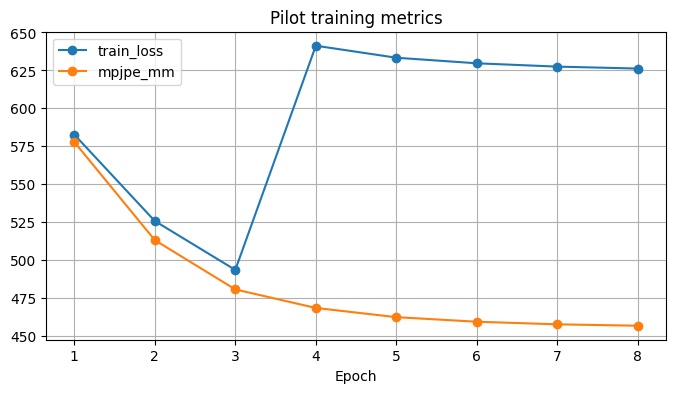

Pilot satisfactory: True


In [94]:
# Decide whether to scale up and train on larger sample
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(history['epoch'], history['loss'], marker='o', label='train_loss')
plt.plot(history['epoch'], history['mpjpe_mm'], marker='o', label='mpjpe_mm')
plt.xlabel('Epoch')
plt.title('Pilot training metrics')
plt.grid(True)
plt.legend()
plt.show()

# Rule of thumb: if MPJPE goes down steadily and no divergence, proceed to larger run.
pilot_ok = False
if len(history['mpjpe_mm']) >= 2:
    pilot_ok = history['mpjpe_mm'][-1] <= history['mpjpe_mm'][0]

print('Pilot satisfactory:', pilot_ok)

In [95]:
# Scale-up data preparation only (archive workflow)
# Run this once, then rerun the next training cell as needed.
FULL_DATA_READY = False

if pilot_ok:
    # Prepare full archives if not prepared yet
    download_archives(full_archives)
    extract_archives(full_archives, LOCAL_EXTRACT)

    # Build full frame manifest and matched annotations from extracted videos
    all_videos = []
    for ext in ["*.mp4", "*.avi", "*.mov", "*.mkv"]:
        all_videos.extend(pathlib.Path(LOCAL_EXTRACT).rglob(ext))
    all_videos = sorted(set(all_videos))

    print('Extracted videos available for full run:', len(all_videos))
    full_manifest, full_rel, full_S, full_center, full_scale = sample_frames_with_annotations(
        all_videos,
        LOCAL_FULL_IMG,
        full_target,
        stride=frame_stride
    )
    full_manifest.to_csv(os.path.join(LOCAL_META, 'full_manifest.csv'), index=False)
    np.savez(
        os.path.join(LOCAL_META, 'full_annotations.npz'),
        rel=full_rel,
        S=full_S,
        center=full_center,
        scale=full_scale,
    )
    print('Full sampled frames:', len(full_manifest))
    print('Full annotations rows:', len(full_rel))

    # Merge full annotations into GT lookup for optional MPJPE supervision
    gt_lookup.update(build_gt_lookup_from_pilot_annotations(os.path.join(LOCAL_META, 'full_annotations.npz')))

    full_ds = H36MImageDataset(LOCAL_FULL_IMG, full_manifest, train_transform, gt_lookup=gt_lookup)
    full_loader = DataLoader(full_ds, batch_size=24, shuffle=True, num_workers=2, collate_fn=collate_fn)

    FULL_EPOCHS = 10
    full_hist = {'epoch': [], 'loss': [], 'mpjpe_mm': []}
    FULL_DATA_READY = len(full_manifest) > 0
    print('Full data ready:', FULL_DATA_READY)
else:
    print('Pilot was not satisfactory; adjust data quality, LR, or supervision mix before full run.')

Downloaded 10/61 archives
Downloaded 20/61 archives
Downloaded 30/61 archives
Downloaded 40/61 archives
Downloaded 50/61 archives
Downloaded 60/61 archives


/tmp/ipykernel_499/524838307.py:33: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(out_root)


Extracted 10/61 archives
Extracted 20/61 archives
Extracted 30/61 archives
Extracted 40/61 archives
Extracted 50/61 archives
Extracted 60/61 archives
Extracted videos available for full run: 640
Videos with matched D3 cdf: 600
Full sampled frames: 20000
Full annotations rows: 20000
Full data ready: True


In [ ]:
# Full training on prepared full dataset (rerunnable without re-unpacking)
if not pilot_ok:
    print('Pilot was not satisfactory; skipping full training.')
elif (not globals().get('FULL_DATA_READY', False)) or ('full_loader' not in globals()):
    print('Full dataset is not prepared. Run the previous cell first.')
else:
    # Two-phase schedule for full run, with strong shape priority in both phases.
    FULL_PHASE1_EPOCHS = min(4, FULL_EPOCHS)
    FPH1_W_POSE = 0.5
    FPH1_W_SHAPE = 2.4
    FPH1_W_CAM = 0.05
    FPH1_W_FEAT = 0.05
    FPH1_LAMBDA_MPJPE_P1 = 0.7
    FPH1_LAMBDA_MPJPE_P2 = 0.25
    FPH1_W_BETA_PRIOR = 0.03

    FPH2_W_POSE = 0.6
    FPH2_W_SHAPE = 2.0
    FPH2_W_CAM = 0.05
    FPH2_W_FEAT = 0.05
    FPH2_LAMBDA_MPJPE_P1 = 0.9
    FPH2_LAMBDA_MPJPE_P2 = 0.4
    FPH2_W_BETA_PRIOR = 0.02

    for epoch in range(1, FULL_EPOCHS + 1):
        if epoch <= FULL_PHASE1_EPOCHS:
            W_POSE_FULL = FPH1_W_POSE
            W_SHAPE_FULL = FPH1_W_SHAPE
            W_CAM_FULL = FPH1_W_CAM
            W_FEAT_FULL = FPH1_W_FEAT
            LAMBDA_MPJPE_P1_FULL = FPH1_LAMBDA_MPJPE_P1
            LAMBDA_MPJPE_P2_FULL = FPH1_LAMBDA_MPJPE_P2
            W_BETA_PRIOR_FULL = FPH1_W_BETA_PRIOR
            full_phase_name = 'phase1_shape_dominant'
        else:
            W_POSE_FULL = FPH2_W_POSE
            W_SHAPE_FULL = FPH2_W_SHAPE
            W_CAM_FULL = FPH2_W_CAM
            W_FEAT_FULL = FPH2_W_FEAT
            LAMBDA_MPJPE_P1_FULL = FPH2_LAMBDA_MPJPE_P1
            LAMBDA_MPJPE_P2_FULL = FPH2_LAMBDA_MPJPE_P2
            W_BETA_PRIOR_FULL = FPH2_W_BETA_PRIOR
            full_phase_name = 'phase2_shape_still_dominant'

        adapter.train()
        spin_model.train()
        run_loss, run_mpjpe, n_batches = 0.0, 0.0, 0

        for batch in full_loader:
            imgs = batch['images'].to(device)

            with torch.no_grad():
                x = spin_model.conv1(imgs)
                x = spin_model.bn1(x)
                x = spin_model.relu(x)
                x = spin_model.maxpool(x)
                x = spin_model.layer1(x)
                x = spin_model.layer2(x)
                x = spin_model.layer3(x)
                x = spin_model.layer4(x)
                x = spin_model.avgpool(x)
                teacher_feats = x.view(x.size(0), -1)
                t_pose, t_shape, t_cam = run_regressor(teacher_feats, spin_model)
                vit_feats = vit_model(imgs)

            feats_2k = adapter(vit_feats)
            pred_pose, pred_shape, pred_cam = run_regressor(feats_2k, spin_model)

            loss_pose = torch.nn.functional.mse_loss(pred_pose, t_pose.detach())
            loss_shape = torch.nn.functional.mse_loss(pred_shape, t_shape.detach())
            loss_cam = torch.nn.functional.mse_loss(pred_cam, t_cam.detach())
            loss_feat = torch.nn.functional.mse_loss(feats_2k, teacher_feats.detach())

            loss_mpjpe = torch.tensor(0.0, device=device)
            loss_pa_mpjpe = torch.tensor(0.0, device=device)
            if batch['j3d'] is not None and batch['j3d_mask'] is not None and batch['j3d_mask'].any():
                mask = batch['j3d_mask'].to(device)
                gt_j3d = batch['j3d'].to(device)[mask]

                p_rot = rot6d_to_rotmat(pred_pose[mask]).view(-1, 24, 3, 3)
                pred_shape_smpl = torch.clamp(pred_shape[mask], min=-3.0, max=3.0)
                out = smpl_layer(
                    global_orient=p_rot[:, 0].unsqueeze(1),
                    body_pose=p_rot[:, 1:],
                    betas=pred_shape_smpl,
                    pose2rot=False,
                )

                if j_regressor is not None:
                    pred_j3d = torch.matmul(j_regressor, out.vertices)
                else:
                    pred_j3d = out.joints

                if gt_j3d.shape[1] == 32:
                    gt_j3d = gt_j3d[:, H36M_TO_17]

                J = min(pred_j3d.shape[1], gt_j3d.shape[1])
                pred_j3d = pred_j3d[:, :J]
                gt_j3d = gt_j3d[:, :J]

                pred_rel = pred_j3d - pred_j3d[:, [0]]
                gt_rel = gt_j3d - gt_j3d[:, [0]]

                p1_vals = []
                for bi in range(pred_rel.shape[0]):
                    valid = (gt_rel[bi].abs().sum(dim=-1) > 1e-8)
                    if int(valid.sum().item()) < 3:
                        continue
                    err_b = torch.norm((pred_rel[bi][valid] - gt_rel[bi][valid]) * 1000.0, dim=-1).mean()
                    p1_vals.append(err_b)
                if len(p1_vals) > 0:
                    loss_mpjpe = torch.stack(p1_vals).mean()

                loss_pa_mpjpe = pa_mpjpe_loss_torch(pred_rel, gt_rel)
            loss_beta_prior = (pred_shape ** 2).mean()

            loss = (
                W_POSE_FULL * loss_pose
                + W_SHAPE_FULL * loss_shape
                + W_CAM_FULL * loss_cam
                + W_FEAT_FULL * loss_feat
                + LAMBDA_MPJPE_P1_FULL * loss_mpjpe
                + LAMBDA_MPJPE_P2_FULL * loss_pa_mpjpe
                + W_BETA_PRIOR_FULL * loss_beta_prior
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            run_loss += loss.item()
            run_mpjpe += float(loss_mpjpe.item())
            n_batches += 1

        scheduler.step()
        avg_loss = run_loss / max(1, n_batches)
        avg_mpjpe = run_mpjpe / max(1, n_batches)
        full_hist['epoch'].append(epoch)
        full_hist['loss'].append(avg_loss)
        full_hist['mpjpe_mm'].append(avg_mpjpe)
        print(f"Full epoch {epoch}/{FULL_EPOCHS} ({full_phase_name}): loss={avg_loss:.4f}, mpjpe={avg_mpjpe:.2f}")

    full_ckpt = os.path.join(LOCAL_ROOT, 'vit_adapter_full.pt')
    torch.save({
        'adapter_state_dict': adapter.state_dict(),
        'spin_state_dict': spin_model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'history': full_hist
    }, full_ckpt)
    print('Saved full checkpoint:', full_ckpt)

Full epoch 1/10 (phase1_shape_priority): loss=436.7223, mpjpe=426.73
Full epoch 2/10 (phase1_shape_priority): loss=432.5486, mpjpe=422.70
Full epoch 3/10 (phase1_shape_priority): loss=429.8349, mpjpe=420.16
Full epoch 4/10 (phase1_shape_priority): loss=427.0993, mpjpe=417.42
Full epoch 5/10 (phase2_pose_recovery): loss=564.0934, mpjpe=414.11
Full epoch 6/10 (phase2_pose_recovery): loss=556.6354, mpjpe=409.59
Full epoch 7/10 (phase2_pose_recovery): loss=550.7314, mpjpe=405.61
Full epoch 8/10 (phase2_pose_recovery): loss=547.6671, mpjpe=403.27
Full epoch 9/10 (phase2_pose_recovery): loss=545.1296, mpjpe=401.35
Full epoch 10/10 (phase2_pose_recovery): loss=542.7710, mpjpe=399.58
Saved full checkpoint: /content/h36m_work/vit_adapter_full.pt


## Notes on approximating MoSH for Human3.6M

MoSH itself is not available here, but this recipe gives a close practical alternative for training:
- Use SPIN teacher predictions as initial pseudo-SMPL fits
- Optionally refine a subset with SMPLify and keep only low reprojection-error fits
- Mix pseudo-SMPL losses with available 3D joint losses (MPJPE)
- Keep SPIN backbone frozen and train only ViT adapter + SPIN regressor head first

This follows SPIN's self-improving fit idea while avoiding dependency on proprietary MoSH assets.

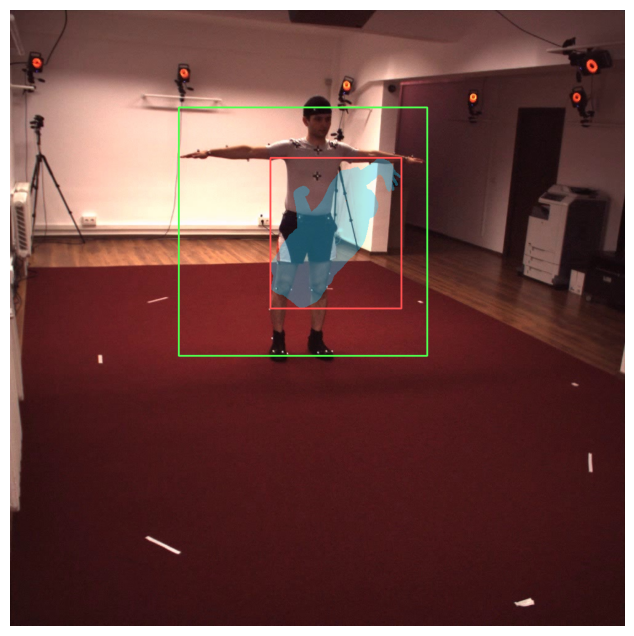

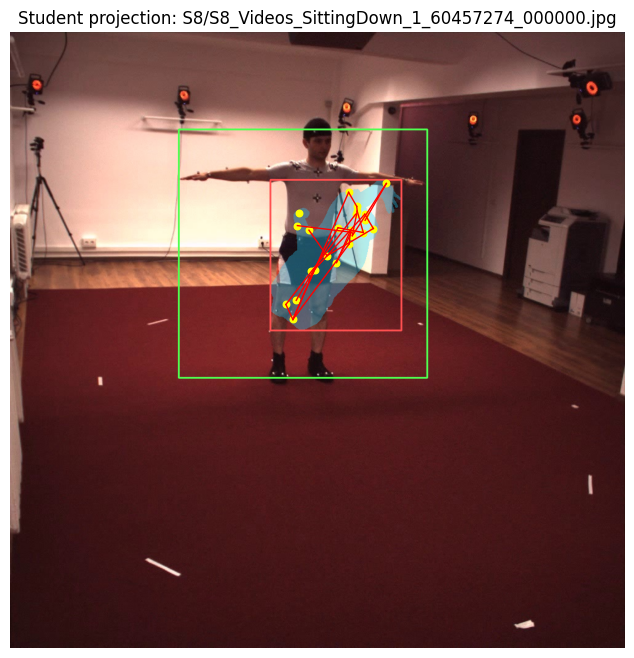

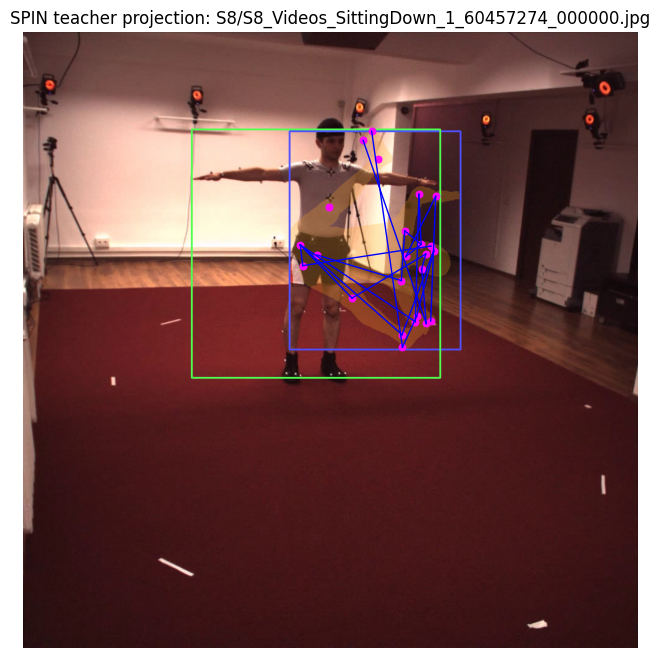

Image: /content/h36m_work/pilot/images/S8/S8_Videos_SittingDown_1_60457274_000000.jpg
Inference crop source: annotation
Selected 2D projection rotation (deg), student: 0
Selected 2D projection rotation (deg), teacher: 90
student pred_cam [scale, tx, ty]: [1.1330272 0.0417968 0.6682791]
student camera_translation [tx, ty, tz]: [-0.0417968  0.6682791 39.401398 ]
teacher pred_cam [scale, tx, ty]: [ 1.3628366  -0.01216274  0.23757443]
teacher camera_translation [tx, ty, tz]: [1.2162739e-02 2.3757443e-01 3.2757309e+01]
Predicted mesh vertices: 6890 faces: 13776
Pred bbox [x1,y1,x2,y2]: [423. 240. 636. 485.]
Ann bbox [x1,y1,x2,y2]: [274.40002 158.40002 677.6     561.6    ]
BBox IoU: 0.321
Center error (px): 53.6
Size ratio (pred/ann): 0.608
Assessment: mismatch is noticeable; projection/camera fit may need calibration.
Teacher bbox [x1,y1,x2,y2]: [433. 161. 711. 516.]
Teacher BBox IoU: 0.498
Teacher center error (px): 98.4
Teacher size ratio (pred/ann): 0.880

Student 3D joints comparison (v

,joint,valid_ann,pred_x_mm,pred_y_mm,pred_z_mm,ann_x_mm,ann_y_mm,ann_z_mm,err_raw_mm,err_bestaxis_mm,err_pa_mm
0,0,1,58.599998,-235.600006,123.599998,-225.800003,820.900024,279.000000,1105.099976,628.200012,857.200012
1,1,1,22.200001,-58.599998,29.700001,-161.600006,413.700012,88.300003,510.200012,385.899994,523.299988
2,2,1,100.199997,-80.900002,-97.500000,-119.000000,-1.800000,-59.200001,236.199997,93.000000,147.100006
3,3,1,55.200001,-269.799988,101.699997,119.000000,2.000000,59.299999,282.399994,322.299988,169.500000
4,4,1,268.799988,-435.600006,136.300003,87.000000,425.799988,183.699997,881.700012,359.100006,348.700012
5,5,1,-79.699997,-116.000000,71.500000,31.600000,839.799988,362.100006,1005.200012,781.500000,981.099976
6,6,1,-3.100000,-372.299988,164.600006,-605.000000,-375.799988,-240.000000,725.299988,1045.500000,786.000000
7,7,1,114.699997,-169.600006,25.299999,-367.600006,-403.299988,-160.899994,567.299988,653.299988,538.599976
8,8,1,-380.600006,403.299988,-325.700012,-94.699997,-460.799988,-156.800003,925.700012,507.700012,261.399994
9,9,1,-404.700012,539.900024,-333.200012,180.100006,-478.500000,-55.700001,1206.800049,362.299988,69.400002



Teacher (SPIN) 3D joints comparison (valid annotation joints only):
Valid joints: 17
Root index used: 14
Best axis sign [x,y,z]: [-1.0, -1.0, -1.0]
MPJPE raw (mm): 907.6
MPJPE best-axis (mm): 711.9
PA-MPJPE (mm): 410.7
Median best-axis error (mm): 759.8
P90 best-axis error (mm): 964.2
Max best-axis error (mm): 1066.5
Delta MPJPE best-axis student-teacher (mm): -178.4


In [97]:
# Visual check: project predicted 3D SMPL mesh back to the original image
# Uses annotation-guided crop for inference, then maps projection back to original frame.
import matplotlib.pyplot as plt
import cv2

try:
    from utils.geometry import perspective_projection
except Exception:
    from SPIN.utils.geometry import perspective_projection

SMPL_EDGES_24 = [
    (0, 1), (1, 4), (4, 7),
    (0, 2), (2, 5), (5, 8),
    (0, 3), (3, 6), (6, 9),
    (9, 13), (13, 16), (16, 18), (18, 20), (20, 22),
    (9, 14), (14, 17), (17, 19), (19, 21), (21, 23),
    (9, 12), (12, 15)
]

def make_mesh_silhouette(vertices_2d, faces, height, width):
    mask = np.zeros((height, width), dtype=np.uint8)
    v = vertices_2d.astype(np.int32)
    for tri in faces:
        pts = v[tri]
        cv2.fillConvexPoly(mask, pts, 255)
    return mask

def overlay_mask(image_rgb, mask, color=(40, 210, 255), alpha=0.35):
    out = image_rgb.copy().astype(np.float32)
    color_arr = np.array(color, dtype=np.float32).reshape(1, 1, 3)
    fg = mask > 0
    out[fg] = (1.0 - alpha) * out[fg] + alpha * color_arr
    return np.clip(out, 0, 255).astype(np.uint8)

def export_smpl_obj(obj_path, vertices, faces):
    with open(obj_path, 'w') as f:
        for v in vertices:
            f.write(f"v {float(v[0])} {float(v[1])} {float(v[2])}\n")
        for tri in faces:
            f.write(f"f {int(tri[0]) + 1} {int(tri[1]) + 1} {int(tri[2]) + 1}\n")

def apply_projection_convention(verts, joints, cam_t):
    cam_vis = cam_t.clone()
    cam_vis[:, 0] *= -1.0
    return verts, joints, cam_vis

def bbox_from_mask(mask):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0 or len(ys) == 0:
        return None
    x1, y1 = int(xs.min()), int(ys.min())
    x2, y2 = int(xs.max()) + 1, int(ys.max()) + 1
    return np.array([x1, y1, x2, y2], dtype=np.float32)

def bbox_from_center_scale(center, scale):
    size = float(scale) * 200.0
    cx, cy = float(center[0]), float(center[1])
    x1 = cx - size / 2.0
    y1 = cy - size / 2.0
    x2 = cx + size / 2.0
    y2 = cy + size / 2.0
    return np.array([x1, y1, x2, y2], dtype=np.float32)

def bbox_iou(a, b):
    ix1 = max(a[0], b[0])
    iy1 = max(a[1], b[1])
    ix2 = min(a[2], b[2])
    iy2 = min(a[3], b[3])
    iw = max(0.0, ix2 - ix1)
    ih = max(0.0, iy2 - iy1)
    inter = iw * ih
    area_a = max(0.0, (a[2] - a[0])) * max(0.0, (a[3] - a[1]))
    area_b = max(0.0, (b[2] - b[0])) * max(0.0, (b[3] - b[1]))
    union = area_a + area_b - inter + 1e-9
    return inter / union

def draw_bbox(img, bbox, color, thickness=2):
    x1, y1, x2, y2 = [int(round(v)) for v in bbox]
    cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)

def crop_square_with_padding(img_rgb, center, scale, out_res):
    # Human3.6M/SPIN convention: scale maps to box size scale*200.
    size = float(scale) * 200.0
    cx, cy = float(center[0]), float(center[1])

    x1 = int(np.floor(cx - size / 2.0))
    y1 = int(np.floor(cy - size / 2.0))
    x2 = int(np.ceil(cx + size / 2.0))
    y2 = int(np.ceil(cy + size / 2.0))

    h, w = img_rgb.shape[:2]
    crop_w = max(1, x2 - x1)
    crop_h = max(1, y2 - y1)

    crop = np.zeros((crop_h, crop_w, 3), dtype=img_rgb.dtype)

    src_x1 = max(0, x1)
    src_y1 = max(0, y1)
    src_x2 = min(w, x2)
    src_y2 = min(h, y2)

    dst_x1 = src_x1 - x1
    dst_y1 = src_y1 - y1
    dst_x2 = dst_x1 + (src_x2 - src_x1)
    dst_y2 = dst_y1 + (src_y2 - src_y1)

    if src_x2 > src_x1 and src_y2 > src_y1:
        crop[dst_y1:dst_y2, dst_x1:dst_x2] = img_rgb[src_y1:src_y2, src_x1:src_x2]

    crop_resized = cv2.resize(crop, (out_res, out_res), interpolation=cv2.INTER_LINEAR)

    meta = {
        'x1': float(x1),
        'y1': float(y1),
        'size': float(size),
        'out_res': float(out_res),
    }
    return crop_resized, meta

def uncrop_points(points_xy, meta):
    out = points_xy.copy()
    scale = meta['size'] / meta['out_res']
    out[:, 0] = out[:, 0] * scale + meta['x1']
    out[:, 1] = out[:, 1] * scale + meta['y1']
    return out

def rotate_points_2d(points_xy, angle_deg, center_xy):
    if angle_deg == 0:
        return points_xy.copy()
    a = np.deg2rad(float(angle_deg))
    c, s = np.cos(a), np.sin(a)
    R = np.array([[c, -s], [s, c]], dtype=np.float32)
    p = points_xy - center_xy.reshape(1, 2)
    return (p @ R.T) + center_xy.reshape(1, 2)

def similarity_transform_3d(source, target):
    # Umeyama alignment: returns source aligned to target.
    src = source.copy()
    tgt = target.copy()

    mu_src = src.mean(axis=0, keepdims=True)
    mu_tgt = tgt.mean(axis=0, keepdims=True)

    src0 = src - mu_src
    tgt0 = tgt - mu_tgt

    cov = (src0.T @ tgt0) / max(1, src.shape[0])
    U, S, Vt = np.linalg.svd(cov)
    R = Vt.T @ U.T
    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = Vt.T @ U.T

    var_src = np.sum(src0 ** 2) / max(1, src.shape[0])
    scale = np.sum(S) / (var_src + 1e-9)
    t = mu_tgt[0] - scale * (R @ mu_src[0])

    aligned = (scale * (R @ src.T)).T + t
    return aligned

def compare_3d_joints(pred_j3d_np, ann_j3d_np, ann_conf=None, ann_root_idx=None):
    J = min(pred_j3d_np.shape[0], ann_j3d_np.shape[0])
    pred = pred_j3d_np[:J].copy()
    ann = ann_j3d_np[:J].copy()

    if ann_conf is None:
        valid = np.ones((J,), dtype=bool)
    else:
        valid = np.array(ann_conf[:J] > 0.5, dtype=bool)
        if valid.sum() < 3:
            valid[:] = True

    if ann_root_idx is None or ann_root_idx >= J or not valid[ann_root_idx]:
        valid_idxs = np.where(valid)[0]
        ann_root_idx = int(valid_idxs[0])

    # Root-center with annotation root to avoid root index mismatch effects.
    pred = pred - pred[[ann_root_idx]]
    ann = ann - ann[[ann_root_idx]]

    # Raw comparison
    err_raw_mm = np.linalg.norm((pred - ann) * 1000.0, axis=1)

    # Best axis-sign alignment for Human3.6M camera convention differences.
    sign_candidates = np.array([
        [1, 1, 1], [1, 1, -1], [1, -1, 1], [1, -1, -1],
        [-1, 1, 1], [-1, 1, -1], [-1, -1, 1], [-1, -1, -1]
    ], dtype=np.float32)

    best_sign = sign_candidates[0]
    best_err = np.inf
    best_pred = pred
    for s in sign_candidates:
        p = pred * s.reshape(1, 3)
        e = np.linalg.norm((p[valid] - ann[valid]) * 1000.0, axis=1).mean()
        if e < best_err:
            best_err = float(e)
            best_sign = s.copy()
            best_pred = p

    err_bestaxis_mm = np.linalg.norm((best_pred - ann) * 1000.0, axis=1)

    # PA-MPJPE: similarity alignment on valid joints only.
    aligned_pred = best_pred.copy()
    if valid.sum() >= 3:
        aligned_valid = similarity_transform_3d(best_pred[valid], ann[valid])
        aligned_pred[valid] = aligned_valid
    err_pa_mm = np.linalg.norm((aligned_pred - ann) * 1000.0, axis=1)

    comp_df = pd.DataFrame({
        'joint': np.arange(J, dtype=int),
        'valid_ann': valid.astype(int),
        'pred_x_mm': pred[:, 0] * 1000.0,
        'pred_y_mm': pred[:, 1] * 1000.0,
        'pred_z_mm': pred[:, 2] * 1000.0,
        'ann_x_mm': ann[:, 0] * 1000.0,
        'ann_y_mm': ann[:, 1] * 1000.0,
        'ann_z_mm': ann[:, 2] * 1000.0,
        'err_raw_mm': err_raw_mm,
        'err_bestaxis_mm': err_bestaxis_mm,
        'err_pa_mm': err_pa_mm,
    })

    stats = {
        'root_idx': int(ann_root_idx),
        'num_valid': int(valid.sum()),
        'best_axis_sign': best_sign.tolist(),
        'mpjpe_raw_mm': float(err_raw_mm[valid].mean()),
        'mpjpe_bestaxis_mm': float(err_bestaxis_mm[valid].mean()),
        'pa_mpjpe_mm': float(err_pa_mm[valid].mean()),
        'median_bestaxis_mm': float(np.median(err_bestaxis_mm[valid])),
        'p90_bestaxis_mm': float(np.percentile(err_bestaxis_mm[valid], 90)),
        'max_bestaxis_mm': float(err_bestaxis_mm[valid].max()),
    }
    return comp_df, stats

def project_prediction_on_original(rel_path=None, show_mesh_points=False, show_silhouette=True, export_obj=False, show_mirror_check=False, use_annotation_crop=True, show_spin_teacher=True):
    if rel_path is None:
        if len(pilot_manifest) == 0:
            raise ValueError('pilot_manifest is empty; run data extraction cell first.')
        rel_path = pilot_manifest.sample(1, random_state=42).iloc[0]['rel']

    img_path = os.path.join(LOCAL_PILOT_IMG, rel_path)
    if not os.path.exists(img_path):
        raise FileNotFoundError(f'Image not found: {img_path}')

    img_pil = Image.open(img_path).convert('RGB')
    img_np = np.array(img_pil)
    h0, w0 = img_np.shape[:2]

    # Resolve annotation center/scale for this frame, if present.
    ann_bbox = None
    ann_center = None
    ann_scale = None
    ann_j3d_np = None
    ann_conf = None
    ann_root_idx = None
    nk = normalize_image_key(rel_path)
    if nk in gt_lookup:
        if gt_lookup[nk].get('center', None) is not None and gt_lookup[nk].get('scale', None) is not None:
            ann_center = np.array(gt_lookup[nk]['center'], dtype=np.float32)
            ann_scale = float(gt_lookup[nk]['scale'])
            ann_bbox = bbox_from_center_scale(ann_center, ann_scale)
        if gt_lookup[nk].get('j3d', None) is not None:
            ann_all = np.array(gt_lookup[nk]['j3d'], dtype=np.float32)
            if ann_all.shape[-1] == 4:
                ann_j3d_np = ann_all[:, :3]
                ann_conf = ann_all[:, 3]
            else:
                ann_j3d_np = ann_all[:, :3]
                ann_conf = np.ones((ann_j3d_np.shape[0],), dtype=np.float32)

            # In this notebook's H36M->24 mapping, root is stored at index 14.
            if ann_j3d_np.shape[0] > 14 and ann_conf[14] > 0.5:
                ann_root_idx = 14

    # For SPIN camera, inference should run on a person-centered crop.
    crop_source = 'annotation'
    if use_annotation_crop and ann_center is not None and ann_scale is not None:
        infer_img_np, crop_meta = crop_square_with_padding(img_np, ann_center, ann_scale, IMG_RES)
    else:
        crop_source = 'image_center_fallback'
        fallback_center = np.array([w0 / 2.0, h0 / 2.0], dtype=np.float32)
        fallback_scale = max(w0, h0) / 200.0
        infer_img_np, crop_meta = crop_square_with_padding(img_np, fallback_center, fallback_scale, IMG_RES)

    infer_pil = Image.fromarray(infer_img_np)
    x = train_transform(infer_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        vit_feats = vit_model(x)
        feats_2k = adapter(vit_feats)
        pred_pose, pred_shape, pred_cam = run_regressor(feats_2k, spin_model)

        # Teacher branch on the same crop for direct sanity comparison.
        tx = spin_model.conv1(x)
        tx = spin_model.bn1(tx)
        tx = spin_model.relu(tx)
        tx = spin_model.maxpool(tx)
        tx = spin_model.layer1(tx)
        tx = spin_model.layer2(tx)
        tx = spin_model.layer3(tx)
        tx = spin_model.layer4(tx)
        tx = spin_model.avgpool(tx)
        teacher_feats = tx.view(tx.size(0), -1)
        spin_pose, spin_shape, spin_cam = run_regressor(teacher_feats, spin_model)

        pred_rotmat = rot6d_to_rotmat(pred_pose).view(-1, 24, 3, 3)
        smpl_out = smpl_layer(
            global_orient=pred_rotmat[:, 0].unsqueeze(1),
            body_pose=pred_rotmat[:, 1:],
            betas=pred_shape,
            pose2rot=False
        )

        spin_rotmat = rot6d_to_rotmat(spin_pose).view(-1, 24, 3, 3)
        spin_smpl_out = smpl_layer(
            global_orient=spin_rotmat[:, 0].unsqueeze(1),
            body_pose=spin_rotmat[:, 1:],
            betas=spin_shape,
            pose2rot=False
        )

        pred_j3d = smpl_out.joints[:, :24, :]
        pred_j3d_np = pred_j3d[0].detach().cpu().numpy()
        pred_vertices = smpl_out.vertices

        spin_j3d = spin_smpl_out.joints[:, :24, :]
        spin_j3d_np = spin_j3d[0].detach().cpu().numpy()
        spin_vertices = spin_smpl_out.vertices

        cam_t = torch.stack([
            pred_cam[:, 1],
            pred_cam[:, 2],
            2 * FOCAL_LENGTH / (IMG_RES * pred_cam[:, 0] + 1e-9)
        ], dim=-1)
        spin_cam_t = torch.stack([
            spin_cam[:, 1],
            spin_cam[:, 2],
            2 * FOCAL_LENGTH / (IMG_RES * spin_cam[:, 0] + 1e-9)
        ], dim=-1)

        pred_vertices_vis, pred_j3d_vis, cam_t_vis = apply_projection_convention(pred_vertices, pred_j3d, cam_t)
        spin_vertices_vis, spin_j3d_vis, spin_cam_t_vis = apply_projection_convention(spin_vertices, spin_j3d, spin_cam_t)

        batch = pred_j3d_vis.shape[0]
        rot = torch.eye(3, device=device).unsqueeze(0).expand(batch, -1, -1)
        center_224 = torch.tensor([[IMG_RES / 2.0, IMG_RES / 2.0]], device=device).expand(batch, -1)

        proj_j2d_crop = perspective_projection(
            pred_j3d_vis,
            rotation=rot,
            translation=cam_t_vis,
            focal_length=FOCAL_LENGTH,
            camera_center=center_224,
        )[0].detach().cpu().numpy()

        proj_v2d_crop = perspective_projection(
            pred_vertices_vis,
            rotation=rot,
            translation=cam_t_vis,
            focal_length=FOCAL_LENGTH,
            camera_center=center_224,
        )[0].detach().cpu().numpy()

        spin_proj_j2d_crop = perspective_projection(
            spin_j3d_vis,
            rotation=rot,
            translation=spin_cam_t_vis,
            focal_length=FOCAL_LENGTH,
            camera_center=center_224,
        )[0].detach().cpu().numpy()

        spin_proj_v2d_crop = perspective_projection(
            spin_vertices_vis,
            rotation=rot,
            translation=spin_cam_t_vis,
            focal_length=FOCAL_LENGTH,
            camera_center=center_224,
        )[0].detach().cpu().numpy()

        verts_3d_np = pred_vertices[0].detach().cpu().numpy()

    faces = np.asarray(smpl_layer.faces, dtype=np.int32)

    # Auto-correct sideways projections by testing simple 2D rotations in crop space.
    rot_candidates = [0, 90, -90, 180]
    rot_center = np.array([IMG_RES / 2.0, IMG_RES / 2.0], dtype=np.float32)
    best_angle = 0
    best_score = -1e9
    best_j2d = None
    best_v2d = None
    best_v2d_clip = None
    best_sil = None
    best_bbox = None

    for ang in rot_candidates:
        j2d_crop_try = rotate_points_2d(proj_j2d_crop, ang, rot_center)
        v2d_crop_try = rotate_points_2d(proj_v2d_crop, ang, rot_center)

        j2d_try = uncrop_points(j2d_crop_try, crop_meta)
        v2d_try = uncrop_points(v2d_crop_try, crop_meta)

        v2d_clip_try = v2d_try.copy()
        v2d_clip_try[:, 0] = np.clip(v2d_clip_try[:, 0], 0, w0 - 1)
        v2d_clip_try[:, 1] = np.clip(v2d_clip_try[:, 1], 0, h0 - 1)

        sil_try = make_mesh_silhouette(v2d_clip_try, faces, h0, w0)
        bbox_try = bbox_from_mask(sil_try)
        if bbox_try is None:
            continue

        if ann_bbox is not None:
            iou_try = float(bbox_iou(bbox_try, ann_bbox))
            c_pred = np.array([(bbox_try[0] + bbox_try[2]) / 2.0, (bbox_try[1] + bbox_try[3]) / 2.0], dtype=np.float32)
            c_ann = np.array([float(ann_center[0]), float(ann_center[1])], dtype=np.float32)
            center_penalty = np.linalg.norm(c_pred - c_ann) / max(1.0, float(max(h0, w0)))
            score = iou_try - 0.5 * center_penalty
        else:
            # Fallback: prefer larger visible silhouette coverage.
            score = float((sil_try > 0).mean())

        if score > best_score:
            best_score = score
            best_angle = int(ang)
            best_j2d = j2d_try
            best_v2d = v2d_try
            best_v2d_clip = v2d_clip_try
            best_sil = sil_try
            best_bbox = bbox_try

    j2d = best_j2d if best_j2d is not None else uncrop_points(proj_j2d_crop, crop_meta)
    v2d = best_v2d if best_v2d is not None else uncrop_points(proj_v2d_crop, crop_meta)
    v2d_clip = best_v2d_clip if best_v2d_clip is not None else v2d.copy()
    if best_v2d_clip is None:
        v2d_clip[:, 0] = np.clip(v2d_clip[:, 0], 0, w0 - 1)
        v2d_clip[:, 1] = np.clip(v2d_clip[:, 1], 0, h0 - 1)

    spin_best_angle = None
    spin_j2d = None
    spin_v2d_clip = None
    spin_sil = None
    spin_bbox = None
    if show_spin_teacher:
        spin_best_score = -1e9
        for ang in rot_candidates:
            spin_j2d_crop_try = rotate_points_2d(spin_proj_j2d_crop, ang, rot_center)
            spin_v2d_crop_try = rotate_points_2d(spin_proj_v2d_crop, ang, rot_center)

            spin_j2d_try = uncrop_points(spin_j2d_crop_try, crop_meta)
            spin_v2d_try = uncrop_points(spin_v2d_crop_try, crop_meta)

            spin_v2d_clip_try = spin_v2d_try.copy()
            spin_v2d_clip_try[:, 0] = np.clip(spin_v2d_clip_try[:, 0], 0, w0 - 1)
            spin_v2d_clip_try[:, 1] = np.clip(spin_v2d_clip_try[:, 1], 0, h0 - 1)

            spin_sil_try = make_mesh_silhouette(spin_v2d_clip_try, faces, h0, w0)
            spin_bbox_try = bbox_from_mask(spin_sil_try)
            if spin_bbox_try is None:
                continue

            if ann_bbox is not None:
                spin_iou_try = float(bbox_iou(spin_bbox_try, ann_bbox))
                spin_c_pred = np.array([(spin_bbox_try[0] + spin_bbox_try[2]) / 2.0, (spin_bbox_try[1] + spin_bbox_try[3]) / 2.0], dtype=np.float32)
                spin_c_ann = np.array([float(ann_center[0]), float(ann_center[1])], dtype=np.float32)
                spin_center_penalty = np.linalg.norm(spin_c_pred - spin_c_ann) / max(1.0, float(max(h0, w0)))
                spin_score = spin_iou_try - 0.5 * spin_center_penalty
            else:
                spin_score = float((spin_sil_try > 0).mean())

            if spin_score > spin_best_score:
                spin_best_score = spin_score
                spin_best_angle = int(ang)
                spin_j2d = spin_j2d_try
                spin_v2d_clip = spin_v2d_clip_try
                spin_sil = spin_sil_try
                spin_bbox = spin_bbox_try

        if spin_j2d is None:
            spin_best_angle = 0
            spin_j2d = uncrop_points(spin_proj_j2d_crop, crop_meta)
            spin_v2d = uncrop_points(spin_proj_v2d_crop, crop_meta)
            spin_v2d_clip = spin_v2d.copy()
            spin_v2d_clip[:, 0] = np.clip(spin_v2d_clip[:, 0], 0, w0 - 1)
            spin_v2d_clip[:, 1] = np.clip(spin_v2d_clip[:, 1], 0, h0 - 1)
            spin_sil = make_mesh_silhouette(spin_v2d_clip, faces, h0, w0)
            spin_bbox = bbox_from_mask(spin_sil)

    vis_img_student = img_np.copy()
    sil = best_sil if best_sil is not None else make_mesh_silhouette(v2d_clip, faces, h0, w0)
    pred_bbox = best_bbox if best_bbox is not None else bbox_from_mask(sil)
    if show_silhouette:
        vis_img_student = overlay_mask(vis_img_student, sil, color=(40, 210, 255), alpha=0.35)
    vis_boxes_student = vis_img_student.copy()
    if pred_bbox is not None:
        draw_bbox(vis_boxes_student, pred_bbox, (255, 80, 80), thickness=2)  # red
    if ann_bbox is not None:
        draw_bbox(vis_boxes_student, ann_bbox, (80, 255, 80), thickness=2)   # green

    vis_boxes_teacher = None
    if show_spin_teacher:
        vis_img_teacher = img_np.copy()
        if show_silhouette and spin_sil is not None:
            vis_img_teacher = overlay_mask(vis_img_teacher, spin_sil, color=(255, 170, 40), alpha=0.25)
        vis_boxes_teacher = vis_img_teacher.copy()
        if spin_bbox is not None:
            draw_bbox(vis_boxes_teacher, spin_bbox, (80, 80, 255), thickness=2)  # blue
        if ann_bbox is not None:
            draw_bbox(vis_boxes_teacher, ann_bbox, (80, 255, 80), thickness=2)   # green

    if show_mirror_check:
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        axes[0].imshow(vis_boxes_student)
        axes[0].set_title('Student prediction vs annotation')
        axes[0].axis('off')

        mirror_img = vis_boxes_student[:, ::-1, :]
        axes[1].imshow(mirror_img)
        axes[1].set_title('Mirrored (sanity check)')
        axes[1].axis('off')
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(8, 8))
        plt.imshow(vis_boxes_student)
        plt.axis('off')
        plt.show()

    plt.figure(figsize=(8, 8))
    plt.imshow(vis_boxes_student)
    if show_mesh_points:
        plt.scatter(v2d_clip[:, 0], v2d_clip[:, 1], s=0.05, c='cyan', alpha=0.15)

    plt.scatter(j2d[:, 0], j2d[:, 1], s=22, c='yellow')
    for i, j in SMPL_EDGES_24:
        if i < len(j2d) and j < len(j2d):
            plt.plot([j2d[i, 0], j2d[j, 0]], [j2d[i, 1], j2d[j, 1]], color='red', linewidth=1.0)

    plt.title(f'Student projection: {rel_path}')
    plt.axis('off')
    plt.show()

    if show_spin_teacher and vis_boxes_teacher is not None:
        plt.figure(figsize=(8, 8))
        plt.imshow(vis_boxes_teacher)
        if show_mesh_points and spin_v2d_clip is not None:
            plt.scatter(spin_v2d_clip[:, 0], spin_v2d_clip[:, 1], s=0.05, c='orange', alpha=0.15)
        if spin_j2d is not None:
            plt.scatter(spin_j2d[:, 0], spin_j2d[:, 1], s=22, c='magenta')
            for i, j in SMPL_EDGES_24:
                if i < len(spin_j2d) and j < len(spin_j2d):
                    plt.plot([spin_j2d[i, 0], spin_j2d[j, 0]], [spin_j2d[i, 1], spin_j2d[j, 1]], color='blue', linewidth=1.0)
        plt.title(f'SPIN teacher projection: {rel_path}')
        plt.axis('off')
        plt.show()

    if export_obj:
        rel_stem = os.path.splitext(rel_path.replace('/', '_'))[0]
        obj_dir = os.path.join(LOCAL_ROOT, 'inference_meshes')
        os.makedirs(obj_dir, exist_ok=True)
        obj_path = os.path.join(obj_dir, f'{rel_stem}.obj')
        export_smpl_obj(obj_path, verts_3d_np, faces)
        print('Exported OBJ:', obj_path)

    print('Image:', img_path)
    print('Inference crop source:', crop_source)
    print('Selected 2D projection rotation (deg), student:', best_angle)
    if show_spin_teacher:
        print('Selected 2D projection rotation (deg), teacher:', spin_best_angle)
    print('student pred_cam [scale, tx, ty]:', pred_cam[0].detach().cpu().numpy())
    print('student camera_translation [tx, ty, tz]:', cam_t_vis[0].detach().cpu().numpy())
    if show_spin_teacher:
        print('teacher pred_cam [scale, tx, ty]:', spin_cam[0].detach().cpu().numpy())
        print('teacher camera_translation [tx, ty, tz]:', spin_cam_t_vis[0].detach().cpu().numpy())
    print('Predicted mesh vertices:', int(verts_3d_np.shape[0]), 'faces:', int(faces.shape[0]))

    if pred_bbox is None:
        print('No predicted silhouette bbox found (empty mask).')
    else:
        pred_center = np.array([(pred_bbox[0] + pred_bbox[2]) / 2.0, (pred_bbox[1] + pred_bbox[3]) / 2.0])
        pred_size = max(pred_bbox[2] - pred_bbox[0], pred_bbox[3] - pred_bbox[1])
        print('Pred bbox [x1,y1,x2,y2]:', pred_bbox)

        if ann_bbox is not None:
            ann_center_np = np.array([float(ann_center[0]), float(ann_center[1])])
            ann_size = float(ann_scale) * 200.0
            iou = float(bbox_iou(pred_bbox, ann_bbox))
            center_err = float(np.linalg.norm(pred_center - ann_center_np))
            size_ratio = float(pred_size / (ann_size + 1e-9))

            print('Ann bbox [x1,y1,x2,y2]:', ann_bbox)
            print(f'BBox IoU: {iou:.3f}')
            print(f'Center error (px): {center_err:.1f}')
            print(f'Size ratio (pred/ann): {size_ratio:.3f}')

            if iou >= 0.4 and center_err <= 40 and 0.7 <= size_ratio <= 1.3:
                print('Assessment: looks reasonable against annotation.')
            else:
                print('Assessment: mismatch is noticeable; projection/camera fit may need calibration.')

            if show_spin_teacher and spin_bbox is not None:
                spin_center = np.array([(spin_bbox[0] + spin_bbox[2]) / 2.0, (spin_bbox[1] + spin_bbox[3]) / 2.0])
                spin_size = max(spin_bbox[2] - spin_bbox[0], spin_bbox[3] - spin_bbox[1])
                iou_spin = float(bbox_iou(spin_bbox, ann_bbox))
                center_err_spin = float(np.linalg.norm(spin_center - ann_center_np))
                size_ratio_spin = float(spin_size / (ann_size + 1e-9))
                print('Teacher bbox [x1,y1,x2,y2]:', spin_bbox)
                print(f'Teacher BBox IoU: {iou_spin:.3f}')
                print(f'Teacher center error (px): {center_err_spin:.1f}')
                print(f'Teacher size ratio (pred/ann): {size_ratio_spin:.3f}')
        else:
            print('No annotation center/scale found for this frame in gt_lookup.')

    # 3D joint comparison (predicted vs annotation) when available
    if ann_j3d_np is not None:
        comp_df, stats = compare_3d_joints(
            pred_j3d_np,
            ann_j3d_np,
            ann_conf=ann_conf,
            ann_root_idx=ann_root_idx,
        )
        print('\nStudent 3D joints comparison (valid annotation joints only):')
        print(f"Valid joints: {stats['num_valid']}")
        print(f"Root index used: {stats['root_idx']}")
        print(f"Best axis sign [x,y,z]: {stats['best_axis_sign']}")
        print(f"MPJPE raw (mm): {stats['mpjpe_raw_mm']:.1f}")
        print(f"MPJPE best-axis (mm): {stats['mpjpe_bestaxis_mm']:.1f}")
        print(f"PA-MPJPE (mm): {stats['pa_mpjpe_mm']:.1f}")
        print(f"Median best-axis error (mm): {stats['median_bestaxis_mm']:.1f}")
        print(f"P90 best-axis error (mm): {stats['p90_bestaxis_mm']:.1f}")
        print(f"Max best-axis error (mm): {stats['max_bestaxis_mm']:.1f}")
        display(comp_df.round(1))

        if show_spin_teacher:
            _, stats_spin = compare_3d_joints(
                spin_j3d_np,
                ann_j3d_np,
                ann_conf=ann_conf,
                ann_root_idx=ann_root_idx,
            )
            print('\nTeacher (SPIN) 3D joints comparison (valid annotation joints only):')
            print(f"Valid joints: {stats_spin['num_valid']}")
            print(f"Root index used: {stats_spin['root_idx']}")
            print(f"Best axis sign [x,y,z]: {stats_spin['best_axis_sign']}")
            print(f"MPJPE raw (mm): {stats_spin['mpjpe_raw_mm']:.1f}")
            print(f"MPJPE best-axis (mm): {stats_spin['mpjpe_bestaxis_mm']:.1f}")
            print(f"PA-MPJPE (mm): {stats_spin['pa_mpjpe_mm']:.1f}")
            print(f"Median best-axis error (mm): {stats_spin['median_bestaxis_mm']:.1f}")
            print(f"P90 best-axis error (mm): {stats_spin['p90_bestaxis_mm']:.1f}")
            print(f"Max best-axis error (mm): {stats_spin['max_bestaxis_mm']:.1f}")
            print(f"Delta MPJPE best-axis student-teacher (mm): {stats['mpjpe_bestaxis_mm'] - stats_spin['mpjpe_bestaxis_mm']:+.1f}")
    else:
        print('\nNo annotation 3D joints found for this frame in gt_lookup.')

# Example usage:
# project_prediction_on_original()
# project_prediction_on_original(show_mesh_points=True, show_mirror_check=True)
# project_prediction_on_original(show_silhouette=True, export_obj=True)
# project_prediction_on_original(use_annotation_crop=False)  # fallback mode
project_prediction_on_original()

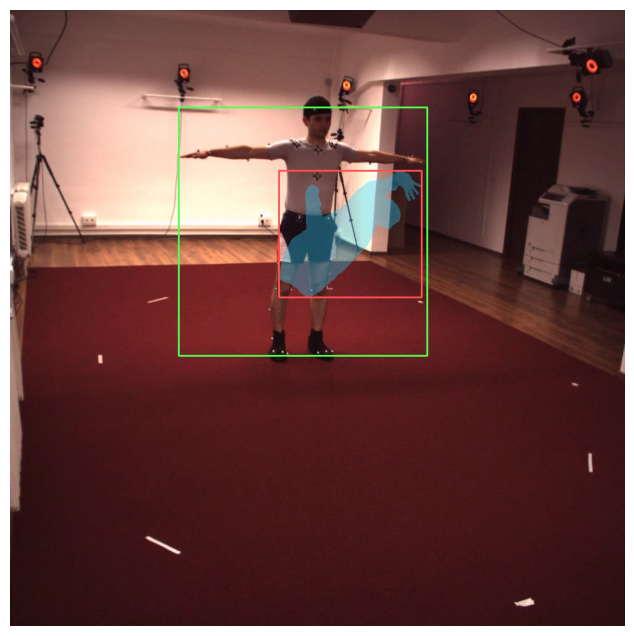

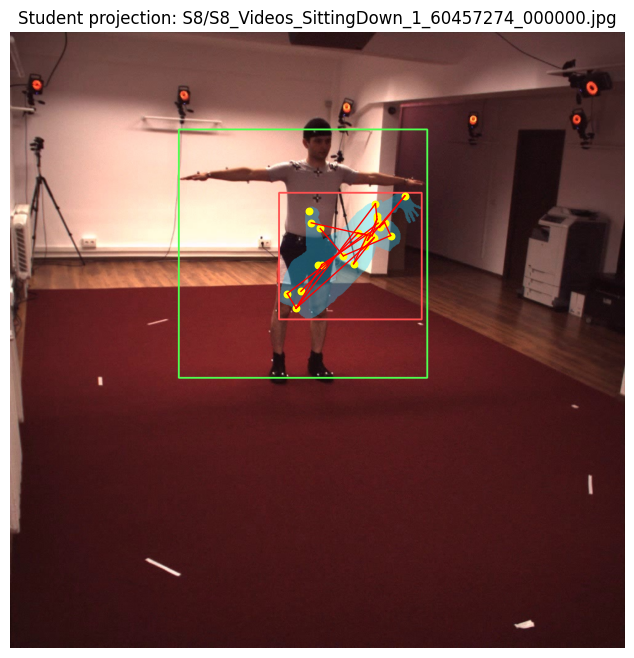

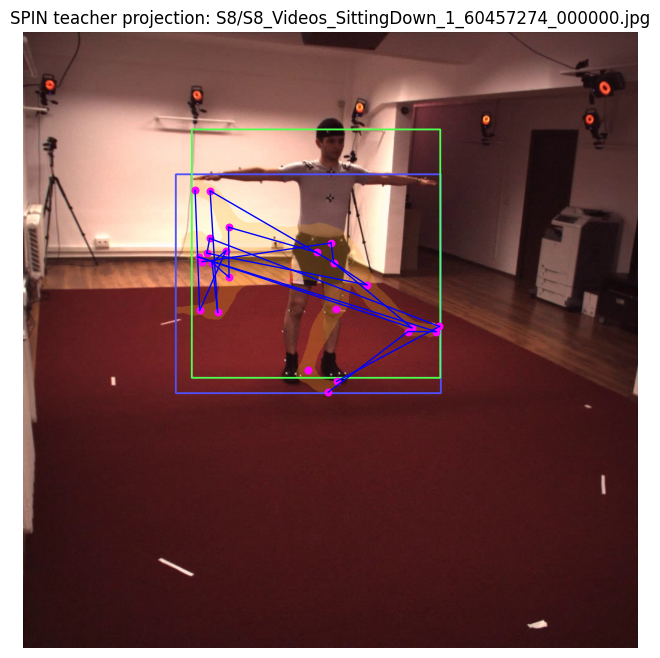

Image: /content/h36m_work/pilot/images/S8/S8_Videos_SittingDown_1_60457274_000000.jpg
Inference crop source: annotation
Selected 2D projection rotation (deg), student: 0
Selected 2D projection rotation (deg), teacher: -90
student pred_cam [scale, tx, ty]: [1.0027707  0.00975514 0.6441225 ]
student camera_translation [tx, ty, tz]: [-9.7551430e-03  6.4412248e-01  4.4519505e+01]
teacher pred_cam [scale, tx, ty]: [ 1.3592091  -0.00821333  0.2589988 ]
teacher camera_translation [tx, ty, tz]: [8.213326e-03 2.589988e-01 3.284473e+01]
Predicted mesh vertices: 6890 faces: 13776
Pred bbox [x1,y1,x2,y2]: [437. 261. 669. 467.]
Ann bbox [x1,y1,x2,y2]: [274.40002 158.40002 677.6     561.6    ]
BBox IoU: 0.294
Center error (px): 77.1
Size ratio (pred/ann): 0.575
Assessment: mismatch is noticeable; projection/camera fit may need calibration.
Teacher bbox [x1,y1,x2,y2]: [248. 231. 679. 587.]
Teacher BBox IoU: 0.730
Teacher center error (px): 50.6
Teacher size ratio (pred/ann): 1.069

Student 3D joints 

,joint,valid_ann,pred_x_mm,pred_y_mm,pred_z_mm,ann_x_mm,ann_y_mm,ann_z_mm,err_raw_mm,err_bestaxis_mm,err_pa_mm
0,0,1,94.599998,-219.399994,108.599998,-225.800003,820.900024,279.000000,1101.800049,638.700012,855.700012
1,1,1,15.600000,-49.000000,13.600000,-161.600006,413.700012,88.300003,501.000000,399.799988,525.000000
2,2,1,53.200001,-85.599998,-127.699997,-119.000000,-1.800000,-59.200001,203.500000,129.100006,141.199997
3,3,1,92.800003,-242.600006,112.000000,119.000000,2.000000,59.299999,251.600006,324.899994,175.899994
4,4,1,320.700012,-409.799988,77.300003,87.000000,425.799988,183.699997,874.200012,421.700012,348.799988
5,5,1,-60.299999,-107.500000,94.000000,31.600000,839.799988,362.100006,988.799988,780.400024,978.700012
6,6,1,83.199997,-345.799988,189.899994,-605.000000,-375.799988,-240.000000,812.000000,988.900024,786.599976
7,7,1,114.199997,-153.000000,-18.100000,-367.600006,-403.299988,-160.899994,561.400024,627.700012,534.299988
8,8,1,-522.599976,363.600006,-229.800003,-94.699997,-460.799988,-156.800003,931.700012,629.200012,256.700012
9,9,1,-561.500000,499.100006,-232.399994,180.100006,-478.500000,-55.700001,1239.699951,420.799988,76.300003



Teacher (SPIN) 3D joints comparison (valid annotation joints only):
Valid joints: 17
Root index used: 14
Best axis sign [x,y,z]: [-1.0, 1.0, 1.0]
MPJPE raw (mm): 1201.1
MPJPE best-axis (mm): 1125.1
PA-MPJPE (mm): 435.3
Median best-axis error (mm): 990.5
P90 best-axis error (mm): 2136.0
Max best-axis error (mm): 2281.1
Delta MPJPE best-axis student-teacher (mm): -582.0


In [98]:
# Stable inference: disable dropout/stochastic layers before 2D/3D comparison
spin_model.eval()
adapter.eval()

with torch.no_grad():
    project_prediction_on_original()

In [99]:
# Audit: what is missing between student prediction and supervision sources
# - pose/shape/camera/feat are compared against teacher (SPIN backbone+regressor output)
# - MPJPE is compared against real dataset 3D annotations when available
import numpy as np
import torch


def list_trainable_parameters():
    trainable = []

    for n, p in adapter.named_parameters():
        if p.requires_grad:
            trainable.append((f"adapter.{n}", p.numel()))

    for n, p in spin_model.named_parameters():
        if p.requires_grad:
            trainable.append((f"spin_model.{n}", p.numel()))

    total = int(sum(v for _, v in trainable))

    groups = {
        'adapter': int(sum(v for n, v in trainable if n.startswith('adapter.'))),
        'spin_fc1_fc2_dec': int(sum(v for n, v in trainable if n.startswith('spin_model.'))),
    }
    names = [n for n, _ in trainable]
    return trainable, total, groups, names


def count_annotated_examples(manifest_df, lookup):
    total = len(manifest_df)
    ann_count = 0
    for rel in manifest_df['rel'].tolist():
        k = normalize_image_key(rel)
        if k in lookup and lookup[k].get('j3d', None) is not None:
            ann_count += 1
    return total, ann_count


def joint_error_mm(pred_j3d_m, gt_j3d_m):
    # pred_j3d_m, gt_j3d_m: [B, J, 3] in meters
    B, J, _ = pred_j3d_m.shape
    errs = []
    for b in range(B):
        gt = gt_j3d_m[b]
        pred = pred_j3d_m[b]

        valid = (gt.abs().sum(dim=-1) > 1e-8)
        if valid.sum() < 3:
            continue

        # Prefer mapped H36M root location if available, else first valid joint.
        root_idx = 14 if (J > 14 and valid[14]) else int(torch.where(valid)[0][0].item())

        gt_rel = gt - gt[root_idx:root_idx+1]
        pred_rel = pred - pred[root_idx:root_idx+1]

        e = torch.norm((pred_rel[valid] - gt_rel[valid]) * 1000.0, dim=-1).mean()
        errs.append(float(e.item()))

    if len(errs) == 0:
        return None
    return float(np.mean(errs))


def audit_student_vs_supervision(num_batches=20):
    spin_model.eval()
    adapter.eval()
    vit_model.eval()

    metrics = {
        'pose_mse': [],
        'shape_mse': [],
        'cam_mse': [],
        'feat_mse': [],
        'mpjpe_mm': [],
    }

    with torch.no_grad():
        for step, batch in enumerate(pilot_loader, 1):
            if step > num_batches:
                break

            imgs = batch['images'].to(device)

            # Teacher path: frozen SPIN backbone features -> SPIN regressor
            x = spin_model.conv1(imgs)
            x = spin_model.bn1(x)
            x = spin_model.relu(x)
            x = spin_model.maxpool(x)
            x = spin_model.layer1(x)
            x = spin_model.layer2(x)
            x = spin_model.layer3(x)
            x = spin_model.layer4(x)
            x = spin_model.avgpool(x)
            teacher_feats = x.view(x.size(0), -1)
            t_pose, t_shape, t_cam = run_regressor(teacher_feats, spin_model)

            # Student path: ViT -> adapter -> SPIN regressor head
            vit_feats = vit_model(imgs)
            feats_2k = adapter(vit_feats)
            pred_pose, pred_shape, pred_cam = run_regressor(feats_2k, spin_model)

            metrics['pose_mse'].append(float(torch.nn.functional.mse_loss(pred_pose, t_pose).item()))
            metrics['shape_mse'].append(float(torch.nn.functional.mse_loss(pred_shape, t_shape).item()))
            metrics['cam_mse'].append(float(torch.nn.functional.mse_loss(pred_cam, t_cam).item()))
            metrics['feat_mse'].append(float(torch.nn.functional.mse_loss(feats_2k, teacher_feats).item()))

            # MPJPE vs real annotations (if present in this batch)
            if batch['j3d'] is not None and batch['j3d_mask'] is not None and batch['j3d_mask'].any():
                mask = batch['j3d_mask'].to(device)
                gt_j3d = batch['j3d'].to(device)[mask]

                p_rot = rot6d_to_rotmat(pred_pose[mask]).view(-1, 24, 3, 3)
                out = smpl_layer(
                    global_orient=p_rot[:, 0].unsqueeze(1),
                    body_pose=p_rot[:, 1:],
                    betas=pred_shape[mask],
                    pose2rot=False,
                )

                if j_regressor is not None:
                    pred_j3d = torch.matmul(j_regressor, out.vertices)
                else:
                    pred_j3d = out.joints

                # Ensure comparable joint count.
                J = min(pred_j3d.shape[1], gt_j3d.shape[1])
                pred_j3d = pred_j3d[:, :J]
                gt_j3d = gt_j3d[:, :J]

                mpjpe_val = joint_error_mm(pred_j3d, gt_j3d)
                if mpjpe_val is not None:
                    metrics['mpjpe_mm'].append(mpjpe_val)

    summary = {}
    for k, vals in metrics.items():
        summary[k] = float(np.mean(vals)) if len(vals) > 0 else None

    return summary


# 1) What is trained?
trainable_params, trainable_total, group_counts, trainable_names = list_trainable_parameters()
print('Trainable layer families:')
print(' - adapter:', group_counts['adapter'])
print(' - spin fc/dec heads:', group_counts['spin_fc1_fc2_dec'])
print(' - total trainable:', trainable_total)
print('Trainable parameter tensors:', len(trainable_names))
print('Examples:', trainable_names[:10])

# 2) How many annotated examples are used?
pilot_total, pilot_annot = count_annotated_examples(pilot_manifest, gt_lookup)
print('\nAnnotated examples in pilot manifest:')
print(f' - total pilot samples: {pilot_total:,}')
print(f' - with 3D annotation: {pilot_annot:,} ({(100.0 * pilot_annot / max(1, pilot_total)):.1f}%)')

# 3) Compare student vs supervision signals
summary = audit_student_vs_supervision(num_batches=20)
print('\nComparison summary over up to 20 pilot batches:')
print(f" - pose_mse (student vs teacher): {summary['pose_mse']:.6f}" if summary['pose_mse'] is not None else ' - pose_mse: n/a')
print(f" - shape_mse (student vs teacher): {summary['shape_mse']:.6f}" if summary['shape_mse'] is not None else ' - shape_mse: n/a')
print(f" - cam_mse (student vs teacher): {summary['cam_mse']:.6f}" if summary['cam_mse'] is not None else ' - cam_mse: n/a')
print(f" - feat_mse (student vs teacher): {summary['feat_mse']:.6f}" if summary['feat_mse'] is not None else ' - feat_mse: n/a')
print(f" - mpjpe_mm (student vs annotation): {summary['mpjpe_mm']:.1f} mm" if summary['mpjpe_mm'] is not None else ' - mpjpe_mm: n/a')

Trainable layer families:
 - adapter: 2886656
 - spin fc/dec heads: 26977501
 - total trainable: 29864157
Trainable parameter tensors: 173
Examples: ['adapter.0.weight', 'adapter.0.bias', 'adapter.2.weight', 'adapter.2.bias', 'spin_model.conv1.weight', 'spin_model.bn1.weight', 'spin_model.bn1.bias', 'spin_model.layer1.0.conv1.weight', 'spin_model.layer1.0.bn1.weight', 'spin_model.layer1.0.bn1.bias']

Annotated examples in pilot manifest:
 - total pilot samples: 4,000
 - with 3D annotation: 4,000 (100.0%)



Comparison summary over up to 20 pilot batches:
 - pose_mse (student vs teacher): 0.968062
 - shape_mse (student vs teacher): 4.791402
 - cam_mse (student vs teacher): 0.116490
 - feat_mse (student vs teacher): 0.012286
 - mpjpe_mm (student vs annotation): 477.2 mm


In [100]:
# MPJPE Protocol diagnostics + training trend check
# Protocol #1: root-centered MPJPE (no similarity alignment)
# Protocol #2: PA-MPJPE (Procrustes aligned)
import numpy as np
import torch


def procrustes_align_batch(pred_xyz, gt_xyz):
    # pred_xyz, gt_xyz: [J, 3]
    X = pred_xyz.copy()
    Y = gt_xyz.copy()

    muX = X.mean(axis=0, keepdims=True)
    muY = Y.mean(axis=0, keepdims=True)
    X0 = X - muX
    Y0 = Y - muY

    K = X0.T @ Y0
    U, s, Vt = np.linalg.svd(K)
    R = Vt.T @ U.T
    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = Vt.T @ U.T

    varX = np.sum(X0 ** 2)
    scale = np.sum(s) / (varX + 1e-9)
    t = muY[0] - scale * (R @ muX[0])

    X_aligned = (scale * (R @ X.T)).T + t
    return X_aligned


def protocol_metrics_from_batch(pred_j3d, gt_j3d):
    # pred_j3d, gt_j3d: torch [B, J, 3], meters
    p1_vals = []
    p2_vals = []

    B = pred_j3d.shape[0]
    J = min(pred_j3d.shape[1], gt_j3d.shape[1])
    pred_j3d = pred_j3d[:, :J]
    gt_j3d = gt_j3d[:, :J]

    for b in range(B):
        pred = pred_j3d[b]
        gt = gt_j3d[b]

        valid = (gt.abs().sum(dim=-1) > 1e-8)
        if valid.sum() < 3:
            continue

        root_idx = 14 if (J > 14 and valid[14]) else int(torch.where(valid)[0][0].item())

        pred_rel = pred - pred[root_idx:root_idx+1]
        gt_rel = gt - gt[root_idx:root_idx+1]

        pred_np = pred_rel[valid].detach().cpu().numpy()
        gt_np = gt_rel[valid].detach().cpu().numpy()

        # Protocol #1 (MPJPE)
        p1 = np.linalg.norm((pred_np - gt_np) * 1000.0, axis=1).mean()

        # Protocol #2 (PA-MPJPE)
        pred_aligned = procrustes_align_batch(pred_np, gt_np)
        p2 = np.linalg.norm((pred_aligned - gt_np) * 1000.0, axis=1).mean()

        p1_vals.append(float(p1))
        p2_vals.append(float(p2))

    if len(p1_vals) == 0:
        return None, None
    return float(np.mean(p1_vals)), float(np.mean(p2_vals))


def evaluate_protocols(num_batches=20):
    spin_model.eval()
    adapter.eval()
    vit_model.eval()

    p1_all = []
    p2_all = []

    with torch.no_grad():
        for step, batch in enumerate(pilot_loader, 1):
            if step > num_batches:
                break

            if batch['j3d'] is None or batch['j3d_mask'] is None or (not batch['j3d_mask'].any()):
                continue

            imgs = batch['images'].to(device)
            mask = batch['j3d_mask'].to(device)
            gt_j3d = batch['j3d'].to(device)[mask]

            vit_feats = vit_model(imgs)
            feats_2k = adapter(vit_feats)
            pred_pose, pred_shape, _ = run_regressor(feats_2k, spin_model)

            p_rot = rot6d_to_rotmat(pred_pose[mask]).view(-1, 24, 3, 3)
            out = smpl_layer(
                global_orient=p_rot[:, 0].unsqueeze(1),
                body_pose=p_rot[:, 1:],
                betas=pred_shape[mask],
                pose2rot=False,
            )

            if j_regressor is not None:
                pred_j3d = torch.matmul(j_regressor, out.vertices)
            else:
                pred_j3d = out.joints

            p1, p2 = protocol_metrics_from_batch(pred_j3d, gt_j3d)
            if p1 is not None:
                p1_all.append(p1)
                p2_all.append(p2)

    if len(p1_all) == 0:
        return None

    return {
        'protocol_1_mpjpe_mm': float(np.mean(p1_all)),
        'protocol_2_pa_mpjpe_mm': float(np.mean(p2_all)),
        'num_batches_used': int(len(p1_all)),
    }


def training_mpjpe_trend(hist):
    vals = hist.get('mpjpe_mm', []) if isinstance(hist, dict) else []
    if len(vals) == 0:
        return None
    return {
        'first': float(vals[0]),
        'last': float(vals[-1]),
        'best': float(np.min(vals)),
        'delta_last_minus_first': float(vals[-1] - vals[0]),
        'looks_ok': bool(vals[-1] <= vals[0]),
    }


proto = evaluate_protocols(num_batches=20)
trend = training_mpjpe_trend(history)

print('MPJPE Protocols (pilot subset):')
if proto is None:
    print(' - not enough annotated samples in evaluated batches')
else:
    print(f" - Protocol #1 (MPJPE): {proto['protocol_1_mpjpe_mm']:.1f} mm")
    print(f" - Protocol #2 (PA-MPJPE): {proto['protocol_2_pa_mpjpe_mm']:.1f} mm")
    print(f" - evaluated batches: {proto['num_batches_used']}")

print('\nTraining MPJPE trend (from history):')
if trend is None:
    print(' - history/mpjpe_mm not found')
else:
    print(f" - first epoch mpjpe: {trend['first']:.1f} mm")
    print(f" - last epoch mpjpe: {trend['last']:.1f} mm")
    print(f" - best epoch mpjpe: {trend['best']:.1f} mm")
    print(f" - delta (last-first): {trend['delta_last_minus_first']:.1f} mm")
    print(f" - looks ok (decreasing): {trend['looks_ok']}")

MPJPE Protocols (pilot subset):
 - Protocol #1 (MPJPE): 475.8 mm
 - Protocol #2 (PA-MPJPE): 326.1 mm
 - evaluated batches: 20

Training MPJPE trend (from history):
 - first epoch mpjpe: 577.9 mm
 - last epoch mpjpe: 456.8 mm
 - best epoch mpjpe: 456.8 mm
 - delta (last-first): -121.1 mm
 - looks ok (decreasing): True


In [101]:
# Direct comparison: Student (ViT+adapter+SPIN head) vs Teacher (SPIN backbone+head)
# against Human3.6M annotation, including shape-related diagnostics.
import numpy as np
import torch


def _protocol_p1_p2_mm(pred_j3d, gt_j3d):
    # pred_j3d, gt_j3d: [B, J, 3] in meters
    p1_vals, p2_vals = [], []
    B = pred_j3d.shape[0]
    J = min(pred_j3d.shape[1], gt_j3d.shape[1])
    pred_j3d = pred_j3d[:, :J]
    gt_j3d = gt_j3d[:, :J]

    for b in range(B):
        pred = pred_j3d[b]
        gt = gt_j3d[b]

        valid = (gt.abs().sum(dim=-1) > 1e-8)
        if int(valid.sum().item()) < 3:
            continue

        root_idx = 14 if (J > 14 and bool(valid[14])) else int(torch.where(valid)[0][0].item())

        pred_rel = pred - pred[root_idx:root_idx+1]
        gt_rel = gt - gt[root_idx:root_idx+1]

        pred_np = pred_rel[valid].detach().cpu().numpy()
        gt_np = gt_rel[valid].detach().cpu().numpy()

        p1 = np.linalg.norm((pred_np - gt_np) * 1000.0, axis=1).mean()
        pred_aligned = procrustes_align_batch(pred_np, gt_np)
        p2 = np.linalg.norm((pred_aligned - gt_np) * 1000.0, axis=1).mean()

        p1_vals.append(float(p1))
        p2_vals.append(float(p2))

    if len(p1_vals) == 0:
        return None, None
    return float(np.mean(p1_vals)), float(np.mean(p2_vals))


def compare_student_teacher_annotation(num_batches=20):
    spin_model.eval()
    adapter.eval()
    vit_model.eval()

    student_p1, student_p2 = [], []
    teacher_p1, teacher_p2 = [], []

    shape_mse_vals = []
    shape_l2_student_vals = []
    shape_l2_teacher_vals = []

    with torch.no_grad():
        for step, batch in enumerate(pilot_loader, 1):
            if step > num_batches:
                break

            if batch['j3d'] is None or batch['j3d_mask'] is None or (not batch['j3d_mask'].any()):
                continue

            imgs = batch['images'].to(device)
            mask = batch['j3d_mask'].to(device)
            gt_j3d = batch['j3d'].to(device)[mask]
            if gt_j3d.shape[1] == 32:
                gt_j3d = gt_j3d[:, H36M_TO_17]

            # Teacher branch (SPIN backbone -> SPIN head)
            x = spin_model.conv1(imgs)
            x = spin_model.bn1(x)
            x = spin_model.relu(x)
            x = spin_model.maxpool(x)
            x = spin_model.layer1(x)
            x = spin_model.layer2(x)
            x = spin_model.layer3(x)
            x = spin_model.layer4(x)
            x = spin_model.avgpool(x)
            teacher_feats = x.view(x.size(0), -1)
            t_pose, t_shape, _ = run_regressor(teacher_feats, spin_model)

            # Student branch (ViT -> adapter -> SPIN head)
            vit_feats = vit_model(imgs)
            feats_2k = adapter(vit_feats)
            s_pose, s_shape, _ = run_regressor(feats_2k, spin_model)

            shape_mse_vals.append(float(torch.nn.functional.mse_loss(s_shape, t_shape).item()))
            shape_l2_student_vals.append(float(torch.norm(s_shape, dim=1).mean().item()))
            shape_l2_teacher_vals.append(float(torch.norm(t_shape, dim=1).mean().item()))

            # Student joints
            s_rot = rot6d_to_rotmat(s_pose[mask]).view(-1, 24, 3, 3)
            s_out = smpl_layer(
                global_orient=s_rot[:, 0].unsqueeze(1),
                body_pose=s_rot[:, 1:],
                betas=s_shape[mask],
                pose2rot=False,
            )
            if j_regressor is not None:
                s_j3d = torch.matmul(j_regressor, s_out.vertices)
            else:
                s_j3d = s_out.joints

            # Teacher joints
            t_rot = rot6d_to_rotmat(t_pose[mask]).view(-1, 24, 3, 3)
            t_out = smpl_layer(
                global_orient=t_rot[:, 0].unsqueeze(1),
                body_pose=t_rot[:, 1:],
                betas=t_shape[mask],
                pose2rot=False,
            )
            if j_regressor is not None:
                t_j3d = torch.matmul(j_regressor, t_out.vertices)
            else:
                t_j3d = t_out.joints

            s_p1, s_p2 = _protocol_p1_p2_mm(s_j3d, gt_j3d)
            t_p1, t_p2 = _protocol_p1_p2_mm(t_j3d, gt_j3d)

            if s_p1 is not None:
                student_p1.append(s_p1)
                student_p2.append(s_p2)
            if t_p1 is not None:
                teacher_p1.append(t_p1)
                teacher_p2.append(t_p2)

    result = {
        'student_protocol1_mpjpe_mm': float(np.mean(student_p1)) if len(student_p1) else None,
        'student_protocol2_pa_mpjpe_mm': float(np.mean(student_p2)) if len(student_p2) else None,
        'teacher_protocol1_mpjpe_mm': float(np.mean(teacher_p1)) if len(teacher_p1) else None,
        'teacher_protocol2_pa_mpjpe_mm': float(np.mean(teacher_p2)) if len(teacher_p2) else None,
        'shape_student_teacher_mse': float(np.mean(shape_mse_vals)) if len(shape_mse_vals) else None,
        'shape_student_beta_l2': float(np.mean(shape_l2_student_vals)) if len(shape_l2_student_vals) else None,
        'shape_teacher_beta_l2': float(np.mean(shape_l2_teacher_vals)) if len(shape_l2_teacher_vals) else None,
        'num_eval_batches': int(max(len(student_p1), len(teacher_p1))),
    }
    return result


cmp = compare_student_teacher_annotation(num_batches=20)
print('Student vs Teacher vs Annotation (pilot subset):')
for k, v in cmp.items():
    if isinstance(v, float):
        if 'mm' in k:
            print(f' - {k}: {v:.1f}')
        else:
            print(f' - {k}: {v:.6f}')
    else:
        print(f' - {k}: {v}')

if cmp['student_protocol1_mpjpe_mm'] is not None and cmp['teacher_protocol1_mpjpe_mm'] is not None:
    d1 = cmp['student_protocol1_mpjpe_mm'] - cmp['teacher_protocol1_mpjpe_mm']
    d2 = cmp['student_protocol2_pa_mpjpe_mm'] - cmp['teacher_protocol2_pa_mpjpe_mm']
    print('\nDelta student-teacher:')
    print(f' - Protocol #1 delta (student-teacher): {d1:+.1f} mm')
    print(f' - Protocol #2 delta (student-teacher): {d2:+.1f} mm')

Student vs Teacher vs Annotation (pilot subset):
 - student_protocol1_mpjpe_mm: 472.8
 - student_protocol2_pa_mpjpe_mm: 325.0
 - teacher_protocol1_mpjpe_mm: 712.5
 - teacher_protocol2_pa_mpjpe_mm: 409.2
 - shape_student_teacher_mse: 4.852263
 - shape_student_beta_l2: 8.139096
 - shape_teacher_beta_l2: 2.134445
 - num_eval_batches: 20

Delta student-teacher:
 - Protocol #1 delta (student-teacher): -239.8 mm
 - Protocol #2 delta (student-teacher): -84.2 mm
